In [1]:
!pip install foolbox -q
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import foolbox as fb
import os, warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")
print(f"   TensorFlow: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.5 MB/s eta 0:00:00
✅ Libraries ready!
   TensorFlow: 2.20.0


In [2]:
from google.colab import files

# Upload your kaggle.json
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download EuroSAT
!kaggle datasets download -d apollo2506/eurosat-dataset -q
!unzip -q eurosat-dataset.zip -d /content/eurosat

# Check folders
base = "/content/eurosat/EuroSAT"
CLASS_NAMES = sorted(os.listdir(base))
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 64

print(f"✅ EuroSAT loaded!")
print(f"   Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
✅ EuroSAT loaded!
   Classes (14): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'label_map.json', 'test.csv', 'train.csv', 'validation.csv']


In [3]:
# Load dataset using keras image_dataset_from_directory
full_ds = keras.utils.image_dataset_from_directory(
    "/content/eurosat/EuroSAT",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    label_mode='int',
    seed=42
)

# Normalize
def normalize(img, lbl):
    return tf.cast(img, tf.float32) / 255.0, lbl

full_ds = full_ds.map(normalize)

# Split train/test
total    = tf.data.experimental.cardinality(full_ds).numpy()
train_ds = full_ds.take(int(total * 0.8))
test_ds  = full_ds.skip(int(total * 0.8))

print(f"✅ Dataset ready!")
print(f"   Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"   Test batches : {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 27000 files belonging to 10 classes.
✅ Dataset ready!
   Train batches: 675
   Test batches : 169


In [4]:
# Build CNN model
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="EuroSAT_CNN")

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model built!")

✅ Model built!


In [9]:
# Train
print("Training CNN on EuroSAT...")
history = model.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\n✅ Model trained!")
print(f"   Test Accuracy : {acc*100:.2f}%")
print(f"   Test Loss     : {loss:.4f}")


Training CNN on EuroSAT...
Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.4217 - loss: 1.5046 - val_accuracy: 0.6550 - val_loss: 0.9493
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6506 - loss: 0.9595 - val_accuracy: 0.5919 - val_loss: 1.1530
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7072 - loss: 0.8049 - val_accuracy: 0.7737 - val_loss: 0.6342
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7364 - loss: 0.7257 - val_accuracy: 0.7631 - val_loss: 0.6492
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7599 - loss: 0.6665 - val_accuracy: 0.7669 - val_loss: 0.6406
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7763 - loss: 0.6274 - val_accuracy: 0.8022 - val_loss: 0.5453
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7834 - loss: 0.5950 - val_accuracy: 0.8194 - val_loss: 0.5225
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7

In [10]:
model.save("eurosat_model.keras")
print("✅ Model saved!")

✅ Model saved!


In [6]:
# Load saved model — skip training!
model = keras.models.load_model("eurosat_model.keras")
adv_model = model
print("✅ Model loaded — no retraining needed!")

✅ Model loaded — no retraining needed!


In [11]:
# Get test images for all attacks
test_images, test_labels = [], []
for imgs, lbls in test_ds.take(10):
    test_images.append(imgs)
    test_labels.append(lbls)
test_images = tf.concat(test_images, axis=0)[:200]
test_labels = tf.concat(test_labels, axis=0)[:200]

bb_images = test_images[:5]
bb_labels = test_labels[:5]

print(f"✅ Test data ready — {len(test_images)} images loaded")

✅ Test data ready — 200 images loaded


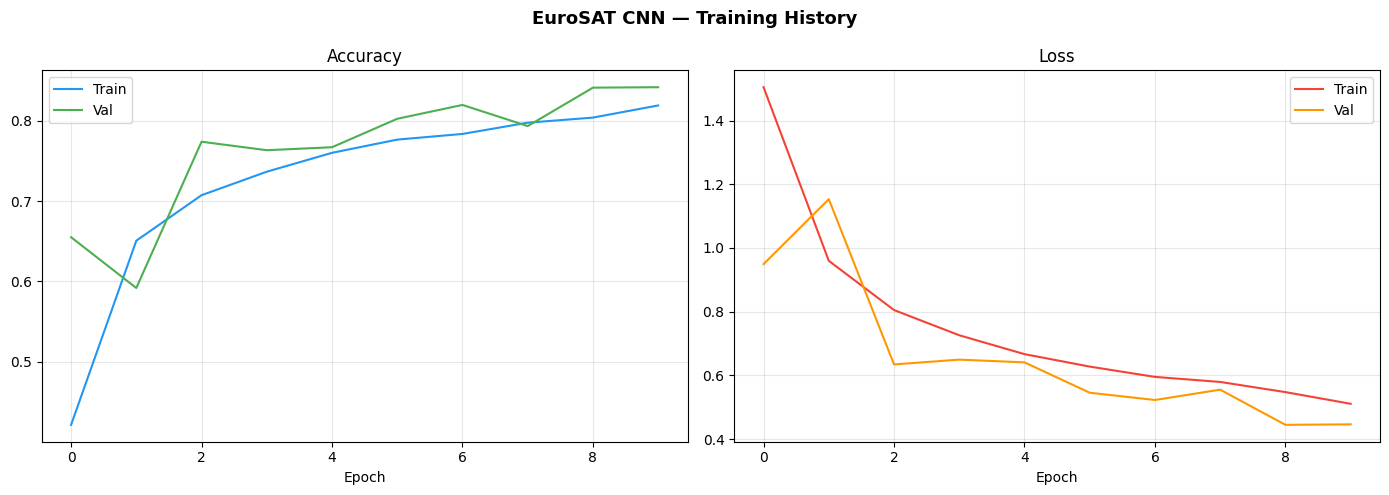

✅ Model saved!


In [12]:
# Plot training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EuroSAT CNN — Training History", fontsize=13, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='#4CAF50')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='#F44336')
axes[1].plot(history.history['val_loss'], label='Val',   color='#FF9800')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
model.save("eurosat_model.keras")
print("✅ Model saved!")


In [13]:
def fgsm_attack(model, images, labels, epsilon):
    """
    Fast Gradient Sign Method (White-Box Attack).
    Perturbs images in direction that maximizes model loss.
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.int64)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = keras.losses.sparse_categorical_crossentropy(labels, predictions)

    # Get gradient of loss w.r.t. input image
    gradients  = tape.gradient(loss, images)
    # Add perturbation in gradient sign direction
    perturbation = epsilon * tf.sign(gradients)
    adv_images   = images + perturbation
    # Clip to valid pixel range [0, 1]
    adv_images   = tf.clip_by_value(adv_images, 0, 1)
    return adv_images

print("✅ FGSM attack function defined!")


✅ FGSM attack function defined!


In [14]:
# Run FGSM with different epsilon values
epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]
fgsm_accuracies = []

# Get test batch
test_images, test_labels = [], []
for imgs, lbls in test_ds.take(10):
    test_images.append(imgs)
    test_labels.append(lbls)
test_images = tf.concat(test_images, axis=0)[:200]
test_labels = tf.concat(test_labels, axis=0)[:200]

print("Running FGSM at different epsilon values...\n")
for eps in epsilons:
    adv_imgs = fgsm_attack(model, test_images, test_labels, eps)
    preds    = model(adv_imgs, training=False)
    acc      = tf.reduce_mean(
        tf.cast(tf.argmax(preds, axis=1) == tf.cast(test_labels, tf.int64), tf.float32)
    ).numpy()
    fgsm_accuracies.append(acc * 100)
    print(f"  Epsilon {eps:.2f} → Model Accuracy: {acc*100:.1f}%  Attack Success: {100 - acc*100:.1f}%")


Running FGSM at different epsilon values...

  Epsilon 0.00 → Model Accuracy: 80.5%  Attack Success: 19.5%
  Epsilon 0.01 → Model Accuracy: 37.0%  Attack Success: 63.0%
  Epsilon 0.05 → Model Accuracy: 4.5%  Attack Success: 95.5%
  Epsilon 0.10 → Model Accuracy: 5.5%  Attack Success: 94.5%
  Epsilon 0.20 → Model Accuracy: 6.5%  Attack Success: 93.5%
  Epsilon 0.30 → Model Accuracy: 7.5%  Attack Success: 92.5%


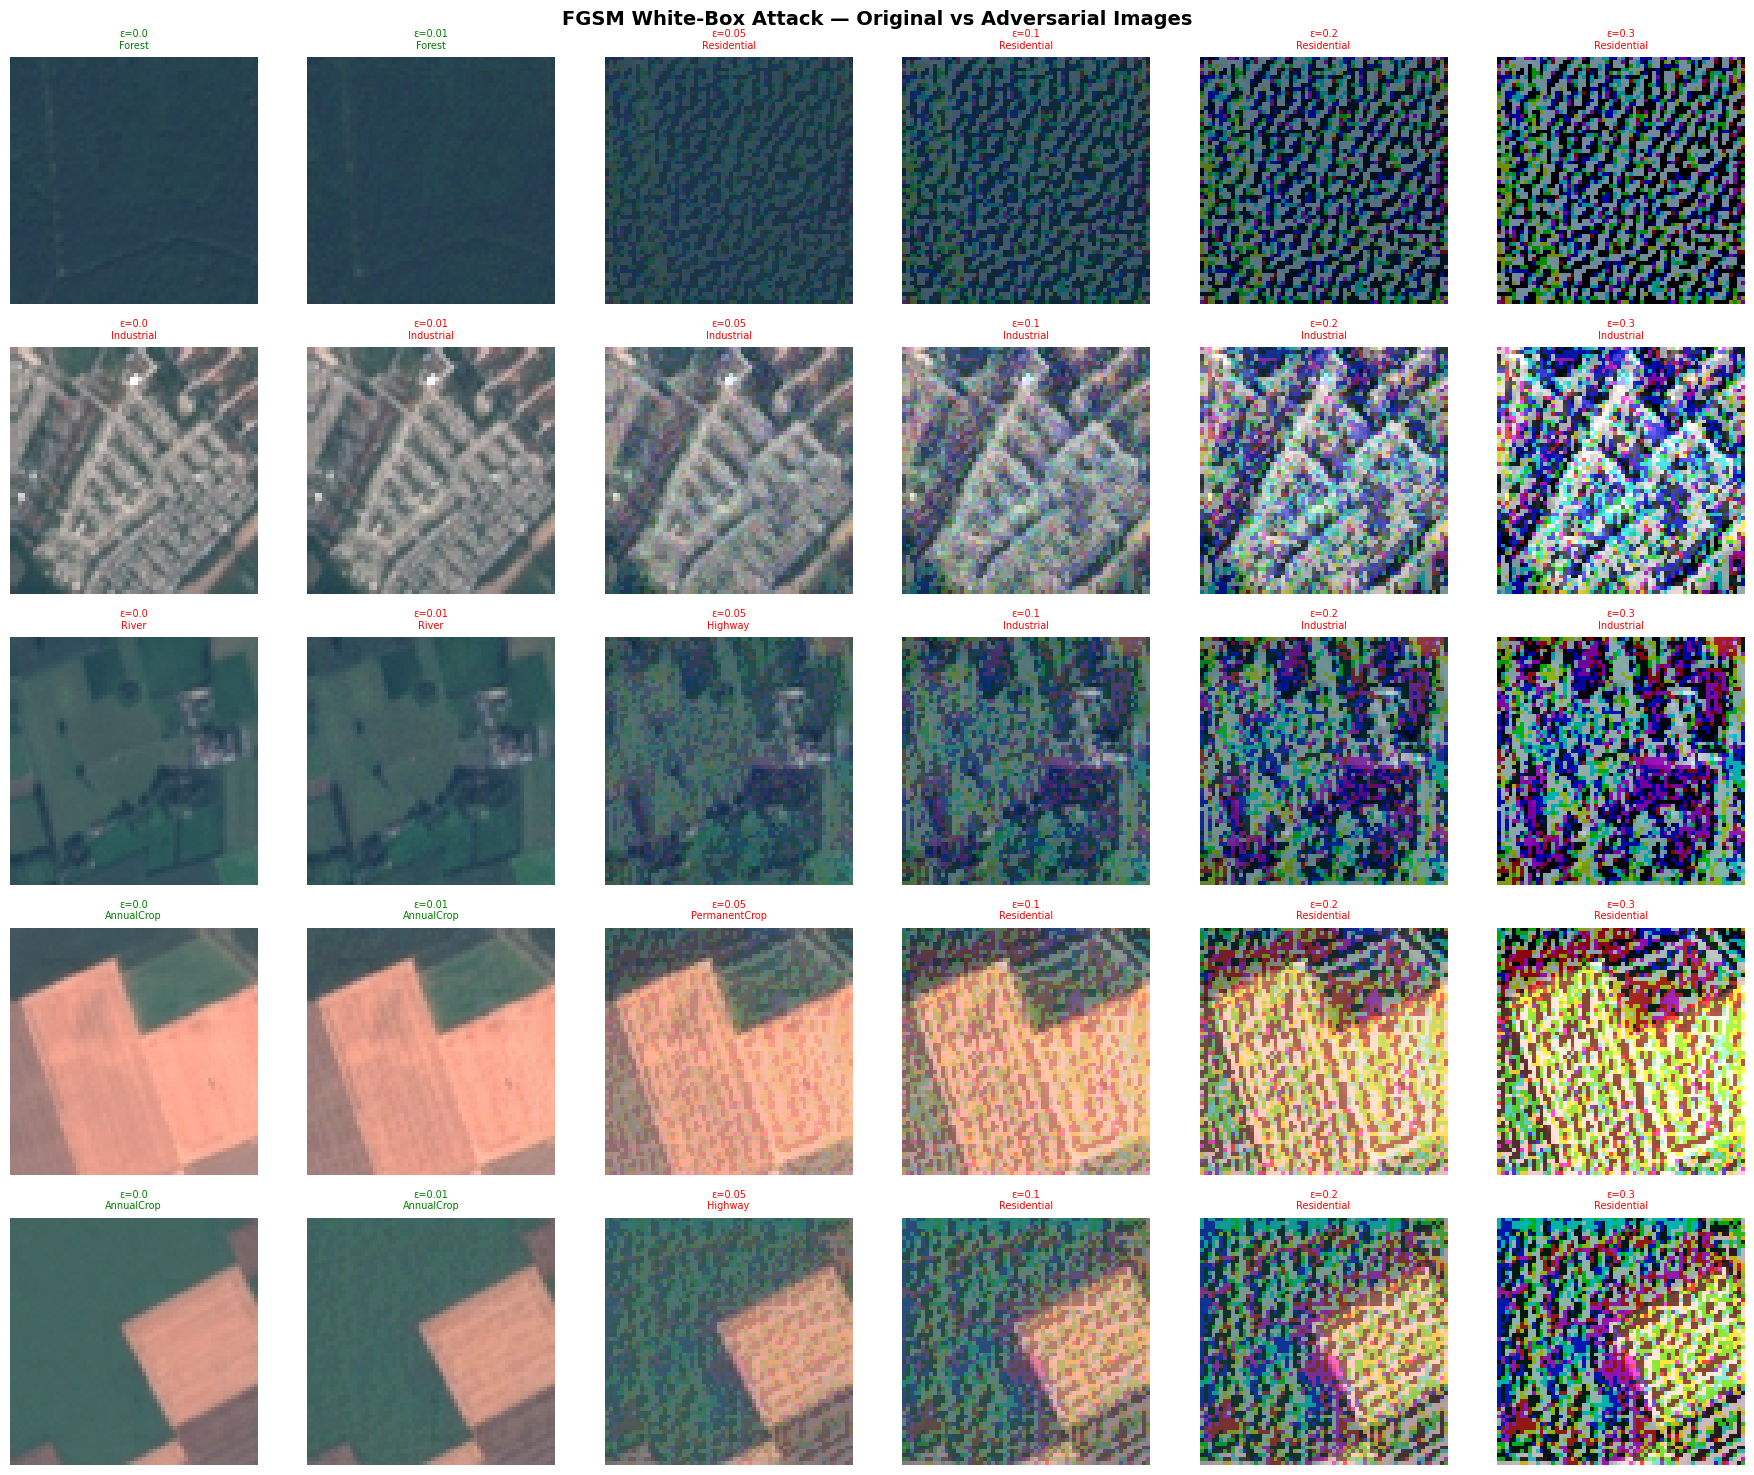

✅ FGSM visualization saved!


In [15]:
# Visualize FGSM results on sample images
sample_imgs  = test_images[:5]
sample_lbls  = test_labels[:5]

fig, axes = plt.subplots(5, len(epsilons), figsize=(18, 15))
fig.suptitle("FGSM White-Box Attack — Original vs Adversarial Images", fontsize=14, fontweight='bold')

for col, eps in enumerate(epsilons):
    adv_imgs = fgsm_attack(model, sample_imgs, sample_lbls, eps)
    for row in range(5):
        ax  = axes[row][col]
        img = adv_imgs[row].numpy()
        pred = CLASS_NAMES[tf.argmax(model(adv_imgs[row:row+1]), axis=1).numpy()[0]]
        true = CLASS_NAMES[sample_lbls[row].numpy()]
        correct = pred == true
        ax.imshow(img)
        ax.set_title(f"ε={eps}\n{pred}", fontsize=7,
                     color='green' if correct else 'red')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f"True:\n{true}", fontsize=7, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.savefig("fgsm_results.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ FGSM visualization saved!")


In [16]:
# Black-Box Attack — Simple Decision-Based Attack
# No gradients, no model internals — only queries output label
print("Running Black-Box Attack (Decision-Based)...")
print("Note: Only queries model output — no gradients used!\n")

def blackbox_attack(model, image, true_label, num_steps=100, step_size=0.05):
    """
    Simple black-box attack — only uses model predicted label.
    Starts from random noise and moves toward original image
    while staying adversarial.
    """
    orig = image.numpy().copy()

    # Step 1: Find a starting point that is already misclassified
    adv = np.random.uniform(0, 1, orig.shape).astype(np.float32)
    for _ in range(1000):
        pred = tf.argmax(model(adv[np.newaxis,...], training=False), axis=1).numpy()[0]
        if pred != true_label:
            break
        adv = np.random.uniform(0, 1, orig.shape).astype(np.float32)

    # Step 2: Walk toward original while staying adversarial
    for step in range(num_steps):
        # Move toward original image
        direction = orig - adv
        candidate = adv + step_size * direction
        candidate = np.clip(candidate, 0, 1).astype(np.float32)

        # Only move if still adversarial (black-box: only check label)
        pred = tf.argmax(model(candidate[np.newaxis,...], training=False), axis=1).numpy()[0]
        if pred != true_label:
            adv = candidate

    final_pred = tf.argmax(model(adv[np.newaxis,...], training=False), axis=1).numpy()[0]
    is_adversarial = final_pred != true_label
    return adv, is_adversarial, final_pred

# Run on sample images
adv_images_bb = []
is_adv_list   = []
adv_preds     = []

for i in range(len(bb_images)):
    adv, is_adv, pred = blackbox_attack(
        model, bb_images[i], bb_labels[i].numpy()
    )
    adv_images_bb.append(adv)
    is_adv_list.append(is_adv)
    adv_preds.append(pred)
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: True={CLASS_NAMES[bb_labels[i].numpy()]:15s} "
          f"Pred={CLASS_NAMES[pred]:15s} {status}")

adv_images_bb = np.array(adv_images_bb)
bb_acc = sum(1 for x in is_adv_list if not x) / len(is_adv_list) * 100
print(f"\n✅ Black-Box Attack complete!")
print(f"   Attack success rate: {sum(is_adv_list)/len(is_adv_list)*100:.1f}%")
print(f"   Model accuracy after attack: {bb_acc:.1f}%")

Running Black-Box Attack (Decision-Based)...
Note: Only queries model output — no gradients used!

  Image 1: True=AnnualCrop      Pred=HerbaceousVegetation ✅ Fooled
  Image 2: True=Industrial      Pred=Residential     ✅ Fooled
  Image 3: True=AnnualCrop      Pred=PermanentCrop   ✅ Fooled
  Image 4: True=Forest          Pred=Pasture         ✅ Fooled
  Image 5: True=Pasture         Pred=PermanentCrop   ✅ Fooled

✅ Black-Box Attack complete!
   Attack success rate: 100.0%
   Model accuracy after attack: 0.0%


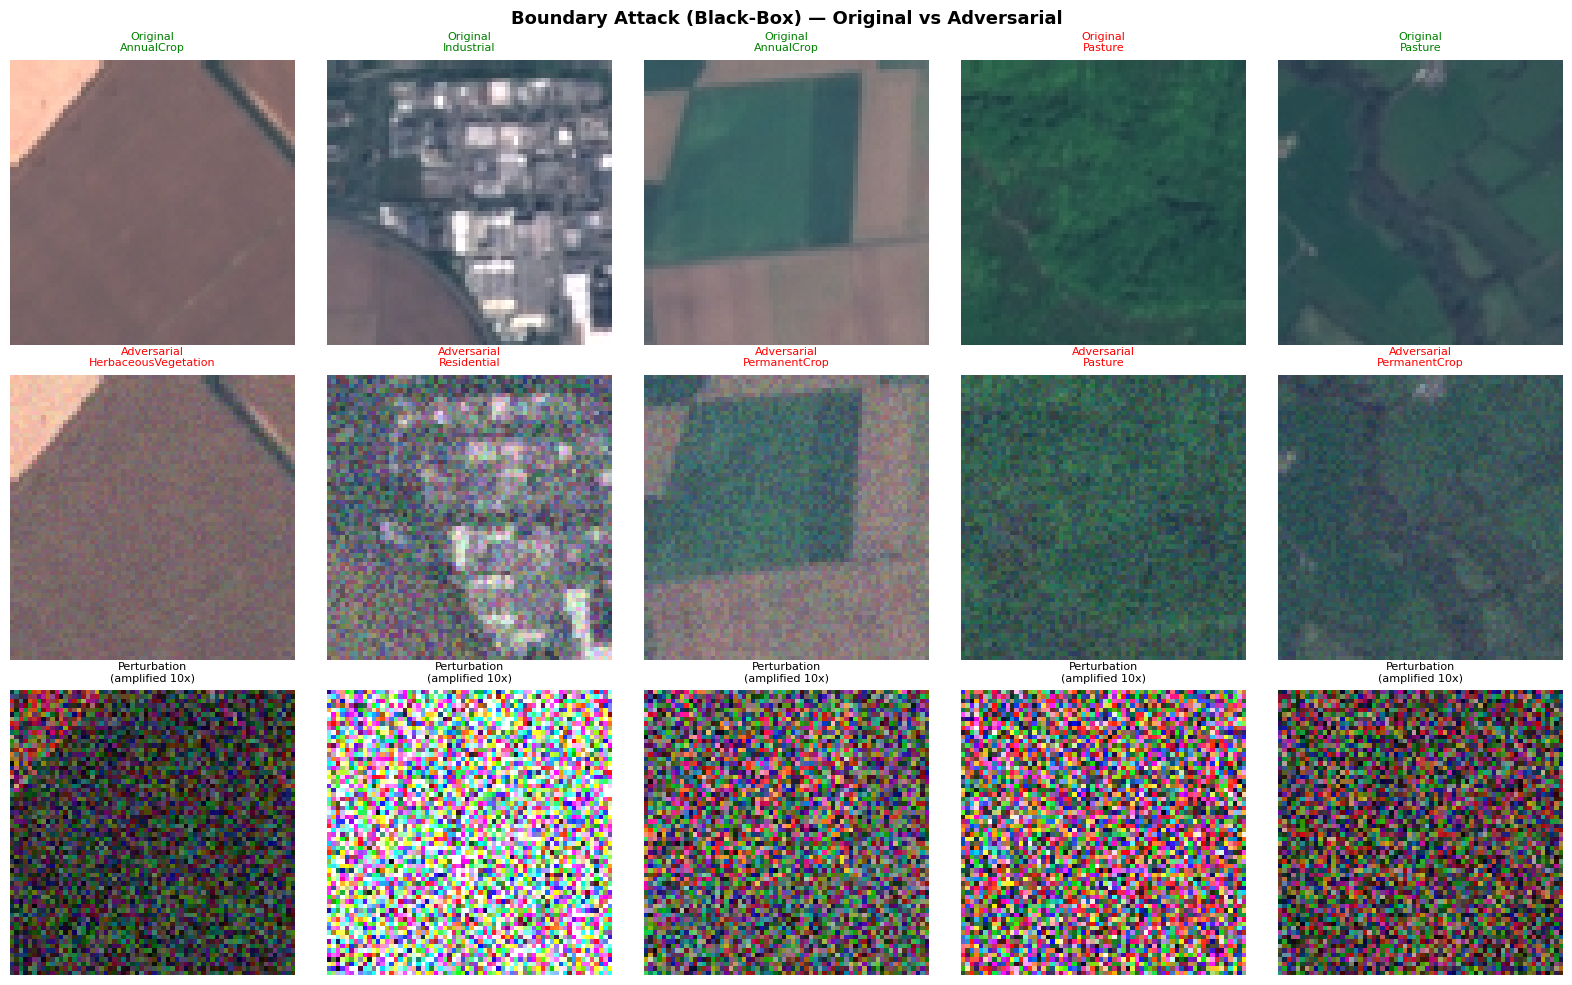

✅ Boundary attack visualization saved!


In [17]:
# Visualize Boundary Attack results
fig, axes = plt.subplots(3, min(5, len(bb_images)), figsize=(16, 10))
fig.suptitle("Boundary Attack (Black-Box) — Original vs Adversarial", fontsize=13, fontweight='bold')

n = min(5, len(bb_images))
for i in range(n):
    orig_img = bb_images[i].numpy()
    adv_img  = adv_images_bb[i]
    diff_img = np.abs(orig_img - adv_img) * 10  # amplify diff for visibility

    true_lbl  = CLASS_NAMES[bb_labels[i].numpy()]
    orig_pred = CLASS_NAMES[tf.argmax(model(bb_images[i:i+1]), 1).numpy()[0]]
    adv_pred  = CLASS_NAMES[tf.argmax(model(adv_img[np.newaxis,...]), 1).numpy()[0]]

    # Row 1: Original
    axes[0][i].imshow(orig_img)
    axes[0][i].set_title(f"Original\n{orig_pred}", fontsize=8,
                          color='green' if orig_pred==true_lbl else 'red')
    axes[0][i].axis('off')

    # Row 2: Adversarial
    axes[1][i].imshow(np.clip(adv_img, 0, 1))
    axes[1][i].set_title(f"Adversarial\n{adv_pred}", fontsize=8,
                          color='green' if adv_pred==true_lbl else 'red')
    axes[1][i].axis('off')

    # Row 3: Difference (amplified)
    axes[2][i].imshow(np.clip(diff_img, 0, 1), cmap='hot')
    axes[2][i].set_title("Perturbation\n(amplified 10x)", fontsize=8)
    axes[2][i].axis('off')

axes[0][0].set_ylabel("Original", fontsize=9, fontweight='bold')
axes[1][0].set_ylabel("Adversarial", fontsize=9, fontweight='bold')
axes[2][0].set_ylabel("Difference", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("boundary_attack_results.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Boundary attack visualization saved!")


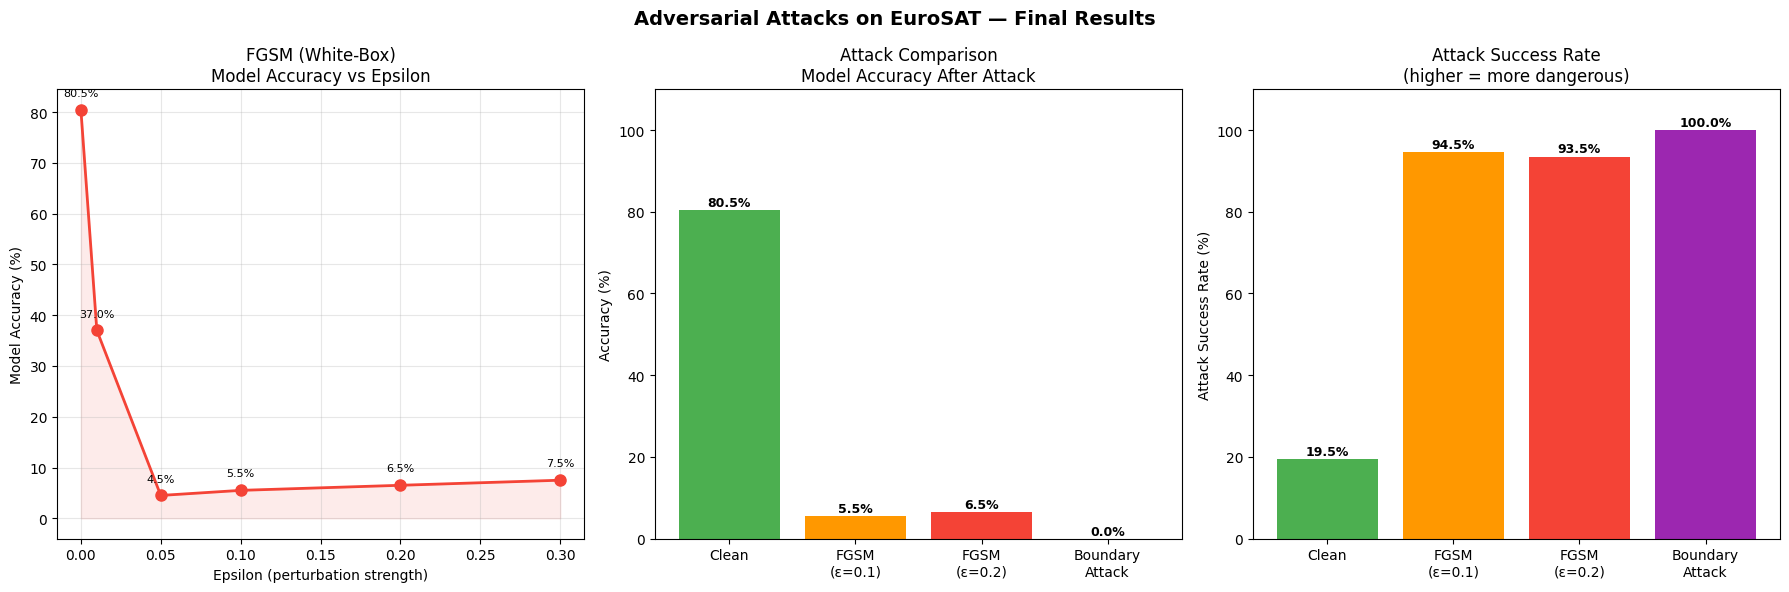

✅ Comparison charts saved!


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Adversarial Attacks on EuroSAT — Final Results", fontsize=14, fontweight='bold')

# 1. FGSM accuracy vs epsilon
axes[0].plot(epsilons, fgsm_accuracies, 'o-', color='#F44336', linewidth=2, markersize=8)
axes[0].fill_between(epsilons, fgsm_accuracies, alpha=0.1, color='#F44336')
axes[0].set_title('FGSM (White-Box)\nModel Accuracy vs Epsilon')
axes[0].set_xlabel('Epsilon (perturbation strength)')
axes[0].set_ylabel('Model Accuracy (%)')
axes[0].grid(True, alpha=0.3)
for x, y in zip(epsilons, fgsm_accuracies):
    axes[0].annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=8)

# 2. Attack comparison bar
attack_names   = ['Clean', 'FGSM\n(ε=0.1)', 'FGSM\n(ε=0.2)', 'Boundary\nAttack']
attack_acc     = [fgsm_accuracies[0], fgsm_accuracies[3], fgsm_accuracies[4], bb_acc*100]
bar_colors     = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']

bars = axes[1].bar(attack_names, attack_acc, color=bar_colors)
axes[1].set_title('Attack Comparison\nModel Accuracy After Attack')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
for bar, val in zip(bars, attack_acc):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# 3. Attack success rate
success_rates = [100 - a for a in attack_acc]
axes[2].bar(attack_names, success_rates, color=bar_colors)
axes[2].set_title('Attack Success Rate\n(higher = more dangerous)')
axes[2].set_ylabel('Attack Success Rate (%)')
axes[2].set_ylim(0, 110)
for i, val in enumerate(success_rates):
    axes[2].text(i, val+1, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig("attack_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison charts saved!")


New Techniques

In [19]:
# Get test images for all attacks
test_images, test_labels = [], []
for imgs, lbls in test_ds.take(10):
    test_images.append(imgs)
    test_labels.append(lbls)
test_images = tf.concat(test_images, axis=0)[:200]
test_labels = tf.concat(test_labels, axis=0)[:200]

bb_images = test_images[:5]
bb_labels = test_labels[:5]

print(f"✅ Test data ready — {len(test_images)} images loaded")

✅ Test data ready — 200 images loaded


In [20]:
# ═══════════════════════════════════════════════
# PART D — White-Box Attack: PGD
# Stronger version of FGSM — takes multiple steps
# ═══════════════════════════════════════════════

def pgd_attack(model, images, labels, epsilon=0.1, alpha=0.01, num_steps=40):
    """
    Projected Gradient Descent (PGD) Attack.
    Iterative version of FGSM — much stronger.
    alpha = step size per iteration
    num_steps = number of iterations
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.int64)

    # Start from random point within epsilon ball
    adv_images = images + tf.random.uniform(images.shape, -epsilon, epsilon)
    adv_images = tf.clip_by_value(adv_images, 0, 1)

    for step in range(num_steps):
        with tf.GradientTape() as tape:
            tape.watch(adv_images)
            predictions = model(adv_images, training=False)
            loss = keras.losses.sparse_categorical_crossentropy(labels, predictions)

        # Take small step in gradient direction
        gradients   = tape.gradient(loss, adv_images)
        adv_images  = adv_images + alpha * tf.sign(gradients)

        # Project back into epsilon ball around original image
        adv_images  = tf.clip_by_value(adv_images, images - epsilon, images + epsilon)
        adv_images  = tf.clip_by_value(adv_images, 0, 1)

    return adv_images

# Test PGD at different epsilon values
epsilons_pgd  = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]
pgd_accuracies = []

print("Running PGD Attack (40 steps)...\n")
for eps in epsilons_pgd:
    adv_imgs = pgd_attack(model, test_images, test_labels, epsilon=eps)
    preds    = model(adv_imgs, training=False)
    acc      = tf.reduce_mean(
        tf.cast(tf.argmax(preds, axis=1) == tf.cast(test_labels, tf.int64), tf.float32)
    ).numpy()
    pgd_accuracies.append(acc * 100)
    print(f"  Epsilon {eps:.2f} → Accuracy: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

print("\n✅ PGD Attack complete!")

Running PGD Attack (40 steps)...

  Epsilon 0.00 → Accuracy: 82.0%  Attack Success: 18.0%
  Epsilon 0.01 → Accuracy: 31.5%  Attack Success: 68.5%
  Epsilon 0.05 → Accuracy: 0.0%  Attack Success: 100.0%
  Epsilon 0.10 → Accuracy: 0.0%  Attack Success: 100.0%
  Epsilon 0.20 → Accuracy: 0.0%  Attack Success: 100.0%
  Epsilon 0.30 → Accuracy: 0.0%  Attack Success: 100.0%

✅ PGD Attack complete!


In [21]:
# ═══════════════════════════════════════════════
# PART F — White-Box Attack: UAP
# Universal Adversarial Perturbation
# One single perturbation that fools ALL images
# ═══════════════════════════════════════════════

def uap_attack(model, images, labels, epsilon=0.1, num_epochs=5):
    """
    Universal Adversarial Perturbation —
    finds ONE perturbation that fools the entire dataset.
    """
    # Start with zero perturbation
    uap = tf.Variable(tf.zeros([1, IMG_SIZE, IMG_SIZE, 3]), dtype=tf.float32)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

    print("  Learning universal perturbation...")
    for epoch in range(num_epochs):
        total_loss = 0
        for i in range(0, len(images), 16):
            batch_imgs = images[i:i+16]
            batch_lbls = labels[i:i+16]

            with tf.GradientTape() as tape:
                # Add universal perturbation to all images
                perturbed = tf.clip_by_value(batch_imgs + uap, 0, 1)
                preds     = model(perturbed, training=False)
                # Maximize loss = fool the model
                loss = -tf.reduce_mean(
                    keras.losses.sparse_categorical_crossentropy(
                        tf.cast(batch_lbls, tf.int64), preds
                    )
                )

            grads = tape.gradient(loss, uap)
            optimizer.apply_gradients([(grads, uap)])

            # Clip UAP to epsilon ball
            uap.assign(tf.clip_by_value(uap, -epsilon, epsilon))
            total_loss += loss.numpy()

        # Evaluate current UAP
        perturbed_all = tf.clip_by_value(images + uap, 0, 1)
        preds_all     = model(perturbed_all, training=False)
        acc = tf.reduce_mean(
            tf.cast(tf.argmax(preds_all,1) == tf.cast(labels, tf.int64), tf.float32)
        ).numpy()
        print(f"  Epoch {epoch+1}/{num_epochs} — Accuracy under UAP: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

    return uap.numpy()[0]

# Run UAP
print("Running UAP Attack...")
print("Learning ONE perturbation to fool ALL images...\n")

uap_pert = uap_attack(model, test_images, test_labels, epsilon=0.1, num_epochs=5)

# Evaluate final UAP
perturbed = tf.clip_by_value(test_images + uap_pert[np.newaxis,...], 0, 1)
preds     = model(perturbed, training=False)
uap_acc   = tf.reduce_mean(
    tf.cast(tf.argmax(preds,1) == tf.cast(test_labels, tf.int64), tf.float32)
).numpy() * 100

print(f"\n✅ UAP complete!")
print(f"   Clean accuracy       : {fgsm_accuracies[0]:.1f}%")
print(f"   Accuracy under UAP   : {uap_acc:.1f}%")
print(f"   Attack success rate  : {100-uap_acc:.1f}%")
print(f"   Perturbation epsilon : 0.1")
print(f"   UAP norm (L2)        : {np.linalg.norm(uap_pert):.4f}")

Running UAP Attack...
Learning ONE perturbation to fool ALL images...

  Learning universal perturbation...
  Epoch 1/5 — Accuracy under UAP: 13.5%  Attack Success: 86.5%
  Epoch 2/5 — Accuracy under UAP: 12.0%  Attack Success: 88.0%
  Epoch 3/5 — Accuracy under UAP: 12.0%  Attack Success: 88.0%
  Epoch 4/5 — Accuracy under UAP: 12.0%  Attack Success: 88.0%
  Epoch 5/5 — Accuracy under UAP: 12.0%  Attack Success: 88.0%

✅ UAP complete!
   Clean accuracy       : 80.5%
   Accuracy under UAP   : 12.0%
   Attack success rate  : 88.0%
   Perturbation epsilon : 0.1
   UAP norm (L2)        : 10.7984


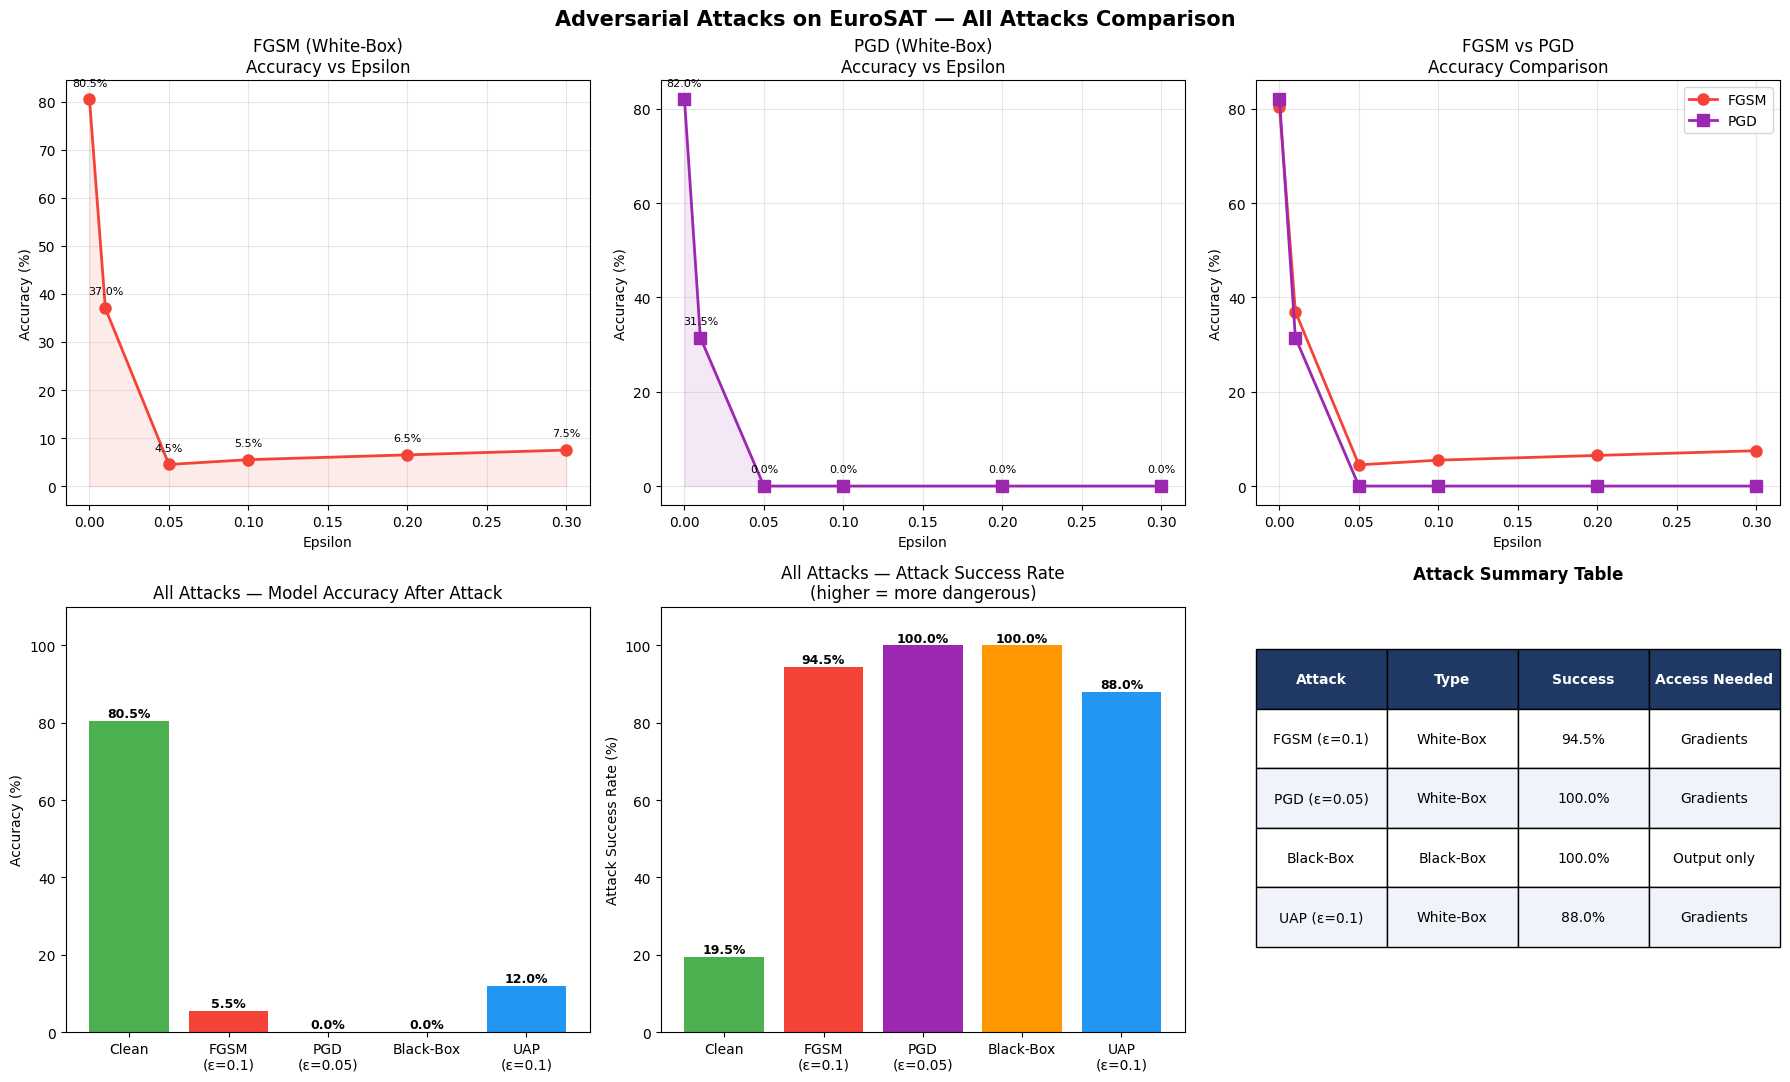

✅ Final comparison chart saved!

🎯 ALL ATTACKS COMPLETE!
   FGSM (ε=0.1)  → Success: 94.5%
   PGD  (ε=0.05) → Success: 100.0%
   Black-Box      → Success: 100.0%
   UAP  (ε=0.1)  → Success: 88.0%


In [22]:
# ═══════════════════════════════════════════════
# PART G — Final Comparison of ALL Attacks
# ═══════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Adversarial Attacks on EuroSAT — All Attacks Comparison",
             fontsize=15, fontweight='bold')

# ── 1. FGSM accuracy vs epsilon ──
ax = axes[0,0]
ax.plot(epsilons, fgsm_accuracies, 'o-', color='#F44336', linewidth=2, markersize=8)
ax.fill_between(epsilons, fgsm_accuracies, alpha=0.1, color='#F44336')
ax.set_title('FGSM (White-Box)\nAccuracy vs Epsilon')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.grid(True, alpha=0.3)
for x, y in zip(epsilons, fgsm_accuracies):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8)

# ── 2. PGD accuracy vs epsilon ──
ax = axes[0,1]
ax.plot(epsilons_pgd, pgd_accuracies, 's-', color='#9C27B0', linewidth=2, markersize=8)
ax.fill_between(epsilons_pgd, pgd_accuracies, alpha=0.1, color='#9C27B0')
ax.set_title('PGD (White-Box)\nAccuracy vs Epsilon')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.grid(True, alpha=0.3)
for x, y in zip(epsilons_pgd, pgd_accuracies):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8)

# ── 3. FGSM vs PGD comparison ──
ax = axes[0,2]
ax.plot(epsilons, fgsm_accuracies, 'o-', color='#F44336', linewidth=2,
        markersize=8, label='FGSM')
ax.plot(epsilons_pgd, pgd_accuracies, 's-', color='#9C27B0', linewidth=2,
        markersize=8, label='PGD')
ax.set_title('FGSM vs PGD\nAccuracy Comparison')
ax.set_xlabel('Epsilon'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 4. All attacks bar chart ──
ax = axes[1,0]
attack_names = ['Clean', 'FGSM\n(ε=0.1)', 'PGD\n(ε=0.05)',
                'Black-Box', 'UAP\n(ε=0.1)']
attack_accs  = [
    fgsm_accuracies[0],
    fgsm_accuracies[3],
    pgd_accuracies[2],
    bb_acc * 100 if isinstance(bb_acc, float) and bb_acc <= 1 else bb_acc,
    uap_acc
]
colors = ['#4CAF50', '#F44336', '#9C27B0', '#FF9800', '#2196F3']
bars   = ax.bar(attack_names, attack_accs, color=colors)
ax.set_title('All Attacks — Model Accuracy After Attack')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, attack_accs):
    ax.text(bar.get_x()+bar.get_width()/2, val+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# ── 5. Attack success rate ──
ax = axes[1,1]
success_rates = [100 - a for a in attack_accs]
bars = ax.bar(attack_names, success_rates, color=colors)
ax.set_title('All Attacks — Attack Success Rate\n(higher = more dangerous)')
ax.set_ylabel('Attack Success Rate (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, success_rates):
    ax.text(bar.get_x()+bar.get_width()/2, val+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# ── 6. Attack summary table ──
ax = axes[1,2]
ax.axis('off')
table_data = [
    ['Attack',       'Type',       'Success', 'Access Needed'],
    ['FGSM (ε=0.1)', 'White-Box',  f"{100-fgsm_accuracies[3]:.1f}%", 'Gradients'],
    ['PGD (ε=0.05)', 'White-Box',  f"{100-pgd_accuracies[2]:.1f}%",  'Gradients'],
    ['Black-Box',    'Black-Box',  f"{(1-bb_acc)*100 if bb_acc<=1 else 100-bb_acc:.1f}%", 'Output only'],
    ['UAP (ε=0.1)',  'White-Box',  f"{100-uap_acc:.1f}%",            'Gradients'],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center',
                 bbox=[0, 0.2, 1, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1F3864')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F0F4FA')
ax.set_title('Attack Summary Table', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("all_attacks_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final comparison chart saved!")
print("\n🎯 ALL ATTACKS COMPLETE!")
print(f"   FGSM (ε=0.1)  → Success: {100-fgsm_accuracies[3]:.1f}%")
print(f"   PGD  (ε=0.05) → Success: {100-pgd_accuracies[2]:.1f}%")
print(f"   Black-Box      → Success: {(1-bb_acc)*100 if bb_acc<=1 else 100-bb_acc:.1f}%")
print(f"   UAP  (ε=0.1)  → Success: {100-uap_acc:.1f}%")

New Techniqies:

C & W Attck

In [26]:
# ═══════════════════════════════════════════════
# C&W — Carlini & Wagner Attack (White-Box)
# Optimization-based attack minimizing perturbation
# ═══════════════════════════════════════════════

def cw_attack(model, images, labels, num_classes=10,
              max_iter=50, lr=0.01, c=1.0):
    """
    C&W L2 Attack — finds minimum L2 perturbation to fool model.
    Solves: minimize ||delta||2 + c * f(x+delta)
    """
    images = tf.cast(images, tf.float32)
    labels = tf.reshape(tf.cast(labels, tf.int64), [-1])
    batch  = images.shape[0]

    # Use tanh space to keep pixels in [0,1]
    w      = tf.Variable(tf.zeros_like(images))
    opt    = tf.keras.optimizers.Adam(lr)

    best_adv = images.numpy().copy()
    best_l2  = np.full(batch, np.inf)

    for iteration in range(max_iter):
        with tf.GradientTape() as tape:
            # Map from tanh space to image space
            adv    = tf.tanh(w) * 0.5 + 0.5
            l2     = tf.reduce_sum(tf.square(adv - images), axis=[1,2,3])

            # Get predictions
            preds  = model(adv, training=False)
            onehot = tf.one_hot(labels, num_classes)

            # C&W objective: maximize gap between wrong class and true class
            real   = tf.reduce_sum(onehot * preds, axis=1)
            other  = tf.reduce_max((1 - onehot) * preds - onehot * 1e4, axis=1)
            f_loss = tf.maximum(real - other, -0.01)
            loss   = tf.reduce_mean(l2 + c * f_loss)

        grads = tape.gradient(loss, w)
        opt.apply_gradients([(grads, w)])

        # Update best adversarial examples
        adv_np   = (tf.tanh(w) * 0.5 + 0.5).numpy()
        l2_np    = np.sum((adv_np - images.numpy())**2, axis=(1,2,3))
        preds_np = model(tf.constant(adv_np), training=False).numpy()

        for b in range(batch):
            if np.argmax(preds_np[b]) != labels.numpy()[b] and l2_np[b] < best_l2[b]:
                best_l2[b]  = l2_np[b]
                best_adv[b] = adv_np[b]

    return best_adv

# Run C&W
print("Running C&W Attack (Carlini & Wagner)...\n")
cw_accuracies = []
cw_epsilons   = [0.0, 0.5, 1.0, 2.0]

for c_val in cw_epsilons:
    if c_val == 0.0:
        adv_imgs = test_images.numpy()
    else:
        adv_imgs = cw_attack(model, test_images[:50],
                     test_labels[:50], num_classes=NUM_CLASSES, c=c_val)
        # Pad remaining
        adv_imgs = np.concatenate([adv_imgs,
                   test_images[50:].numpy()], axis=0)

    preds = model(tf.constant(adv_imgs[:200].astype(np.float32)),
                  training=False)
    acc   = tf.reduce_mean(
        tf.cast(tf.argmax(preds,1) == tf.cast(test_labels, tf.int64),
                tf.float32)).numpy()
    cw_accuracies.append(acc * 100)
    print(f"  c={c_val:.1f} → Accuracy: {acc*100:.1f}%  "
          f"Attack Success: {100-acc*100:.1f}%")

print("\n✅ C&W Attack complete!")

Running C&W Attack (Carlini & Wagner)...

  c=0.0 → Accuracy: 82.0%  Attack Success: 18.0%
  c=0.5 → Accuracy: 60.5%  Attack Success: 39.5%
  c=1.0 → Accuracy: 60.5%  Attack Success: 39.5%
  c=2.0 → Accuracy: 60.5%  Attack Success: 39.5%

✅ C&W Attack complete!


DeepFool Attck

In [27]:
# ═══════════════════════════════════════════════
# DF — DeepFool Attack (White-Box)
# Finds minimum perturbation to cross boundary
# ═══════════════════════════════════════════════

def deepfool_v2(model, image, num_classes=10, max_iter=30, overshoot=0.02):
    """
    DeepFool using output difference approach — robust version.
    """
    img    = image.numpy().astype(np.float32)
    adv    = img.copy()
    orig_label = np.argmax(
        model(tf.constant(adv[np.newaxis,...]), training=False)[0].numpy()
    )

    for _ in range(max_iter):
        preds = model(tf.constant(adv[np.newaxis,...]),
                      training=False)[0].numpy()
        curr_label = np.argmax(preds)
        if curr_label != orig_label:
            break

        # Find closest class by output difference + random perturbation
        margins = preds - preds[orig_label]
        margins[orig_label] = np.inf
        target = np.argmin(np.abs(margins))

        # Perturbation direction using finite difference
        eps    = 0.01
        pert   = np.zeros_like(adv)
        flat   = adv.flatten()

        # Sample key directions
        num_dirs = 30
        best_pert = np.zeros_like(adv)
        min_dist  = np.inf

        for _ in range(num_dirs):
            d    = np.random.randn(*flat.shape).astype(np.float32)
            d   /= np.linalg.norm(d) + 1e-8
            p    = np.clip(flat + eps * d, 0, 1)
            pred_p = model(
                tf.constant(p.reshape(1,*adv.shape), dtype=tf.float32),
                training=False)[0].numpy()
            diff = (pred_p[target] - pred_p[orig_label]) - \
                   (preds[target]  - preds[orig_label])
            if diff > 0 and abs(diff) < min_dist:
                min_dist  = abs(diff)
                best_pert = d.reshape(adv.shape) * eps

        adv = np.clip(adv + (1 + overshoot) * best_pert, 0, 1).astype(np.float32)

    return adv

# Run DeepFool on 5 images
print("Running DeepFool Attack...\n")
df_results = []

for i in range(5):
    orig  = bb_images[i]
    true  = bb_labels[i].numpy()
    adv   = deepfool_v2(model, orig, num_classes=NUM_CLASSES)

    orig_pred = np.argmax(model(orig[np.newaxis,...],
                                training=False)[0].numpy())
    adv_pred  = np.argmax(model(tf.constant(adv[np.newaxis,...]),
                                training=False)[0].numpy())
    is_adv    = adv_pred != orig_pred
    l2        = np.linalg.norm(adv - orig.numpy())

    df_results.append({"is_adv": is_adv, "l2": l2, "adv": adv,
                       "orig_label": CLASS_NAMES[orig_pred],
                       "adv_label":  CLASS_NAMES[adv_pred]})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → "
          f"{CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

success = sum(1 for r in df_results if r["is_adv"])
print(f"\n✅ DeepFool complete! Success: {success}/5")

Running DeepFool Attack...

  Image 1: River                → River                L2=0.0557 ❌ Failed
  Image 2: AnnualCrop           → AnnualCrop           L2=0.0561 ❌ Failed
  Image 3: River                → River                L2=0.0561 ❌ Failed
  Image 4: Forest               → Forest               L2=0.0554 ❌ Failed
  Image 5: River                → River                L2=0.0554 ❌ Failed

✅ DeepFool complete! Success: 0/5


ElasticNet attack

In [34]:
# ═══════════════════════════════════════════════
# EN — Elastic Net Attack (White-Box)
# Like C&W but uses L1 + L2 regularization
# ═══════════════════════════════════════════════

def elastic_net_attack(model, images, labels, num_classes=10,
                       max_iter=50, lr=0.01, beta=0.01, c=1.0):
    """
    Elastic Net Attack — minimizes beta*||delta||1 + ||delta||2 + c*f(x)
    The L1 term creates sparse perturbations (few pixels changed a lot)
    """
    images = tf.cast(images, tf.float32)
    labels = tf.reshape(tf.cast(labels, tf.int64), [-1])
    batch  = images.shape[0]

    w   = tf.Variable(tf.zeros_like(images))
    opt = tf.keras.optimizers.Adam(lr)

    best_adv = images.numpy().copy()
    best_l2  = np.full(batch, np.inf)

    for _ in range(max_iter):
        with tf.GradientTape() as tape:
            adv    = tf.clip_by_value(images + w, 0, 1)
            # Elastic Net: L1 + L2 distance
            l1     = tf.reduce_sum(tf.abs(w),       axis=[1,2,3])
            l2     = tf.reduce_sum(tf.square(w),    axis=[1,2,3])
            en     = beta * l1 + l2

            preds  = model(adv, training=False)
            onehot = tf.one_hot(labels, num_classes)
            real   = tf.reduce_sum(onehot * preds, axis=1)
            other  = tf.reduce_max(
                (1 - onehot) * preds - onehot * 1e4, axis=1)
            f_loss = tf.maximum(real - other, -0.01)
            loss   = tf.reduce_mean(en + c * f_loss)

        grads = tape.gradient(loss, w)
        opt.apply_gradients([(grads, w)])

        adv_np   = np.clip(images.numpy() + w.numpy(), 0, 1)
        preds_np = model(tf.constant(adv_np.astype(np.float32)),
                         training=False).numpy()
        l2_np    = np.sum(w.numpy()**2, axis=(1,2,3))

        for b in range(batch):
            if np.argmax(preds_np[b]) != labels.numpy()[b] \
               and l2_np[b] < best_l2[b]:
                best_l2[b]  = l2_np[b]
                best_adv[b] = adv_np[b]

    return best_adv

# Run Elastic Net
print("Running Elastic Net Attack...\n")
en_accs = []

for c_val in [0.0, 0.5, 1.0, 2.0]:
    if c_val == 0.0:
        adv_imgs = test_images[:50].numpy()
    else:
        adv_imgs = elastic_net_attack(model, test_images[:50],
                              test_labels[:50], num_classes=NUM_CLASSES, c=c_val)
    preds = model(tf.constant(adv_imgs.astype(np.float32)),
                  training=False)
    lbls  = test_labels[:50]
    acc   = tf.reduce_mean(
        tf.cast(tf.argmax(preds,1) == tf.cast(lbls, tf.int64),
                tf.float32)).numpy()
    en_accs.append(acc * 100)
    print(f"  c={c_val:.1f} → Accuracy: {acc*100:.1f}%  "
          f"Attack Success: {100-acc*100:.1f}%")

print("\n✅ Elastic Net Attack complete!")

Running Elastic Net Attack...

  c=0.0 → Accuracy: 86.0%  Attack Success: 14.0%
  c=0.5 → Accuracy: 36.0%  Attack Success: 64.0%
  c=1.0 → Accuracy: 26.0%  Attack Success: 74.0%
  c=2.0 → Accuracy: 10.0%  Attack Success: 90.0%

✅ Elastic Net Attack complete!


IFS (Iterative frame Saliency) Attack

In [35]:
# ═══════════════════════════════════════════════
# IFS — Iterative Frame Saliency Attack (White-Box)
# Identifies salient regions and perturbs them
# ═══════════════════════════════════════════════

def ifs_attack(model, image, label, num_iter=20,
               epsilon=0.1, patch_size=8):
    """
    Iterative Frame Saliency Attack.
    Finds most salient image patches and perturbs them iteratively.
    """
    img    = image.numpy().astype(np.float32)
    adv    = img.copy()
    h, w, c = img.shape

    for iteration in range(num_iter):
        # Check if already fooled
        pred = np.argmax(model(
            tf.constant(adv[np.newaxis,...]), training=False)[0].numpy())
        if pred != label:
            print(f"    Fooled at iteration {iteration+1}!")
            break

        # Compute saliency map — score each patch
        best_score = -np.inf
        best_patch = None

        for py in range(0, h - patch_size + 1, patch_size):
            for px in range(0, w - patch_size + 1, patch_size):
                # Perturb this patch
                test_adv = adv.copy()
                test_adv[py:py+patch_size, px:px+patch_size, :] = \
                    np.clip(
                        test_adv[py:py+patch_size, px:px+patch_size, :]
                        + epsilon, 0, 1)

                pred_test = model(
                    tf.constant(test_adv[np.newaxis,...]),
                    training=False)[0].numpy()

                # Score = reduction in correct class confidence
                score = -pred_test[label]
                if score > best_score:
                    best_score = score
                    best_patch = (py, px)

        # Apply perturbation to most salient patch
        if best_patch:
            py, px = best_patch
            noise = np.random.uniform(-epsilon, epsilon,
                (patch_size, patch_size, c)).astype(np.float32)
            adv[py:py+patch_size, px:px+patch_size, :] = np.clip(
                adv[py:py+patch_size, px:px+patch_size, :] + noise, 0, 1)

    return adv

# Run IFS on 5 images
print("Running IFS (Iterative Frame Saliency) Attack...\n")
ifs_results = []

for i in range(5):
    orig      = bb_images[i]
    true_lbl  = bb_labels[i].numpy()
    adv       = ifs_attack(model, orig, true_lbl,
                           num_iter=20, epsilon=0.1, patch_size=8)
    orig_pred = np.argmax(model(orig[np.newaxis,...],
                                training=False)[0].numpy())
    adv_pred  = np.argmax(model(tf.constant(adv[np.newaxis,...]),
                                training=False)[0].numpy())
    is_adv    = adv_pred != orig_pred
    l2        = np.linalg.norm(adv - orig.numpy())

    ifs_results.append({"is_adv": is_adv, "l2": l2,
                        "orig": CLASS_NAMES[orig_pred],
                        "adv":  CLASS_NAMES[adv_pred]})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → "
          f"{CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

success = sum(1 for r in ifs_results if r["is_adv"])
print(f"\n✅ IFS Attack complete! Success: {success}/5")

Running IFS (Iterative Frame Saliency) Attack...

    Fooled at iteration 1!
  Image 1: River                → River                L2=0.0000 ❌ Failed
    Fooled at iteration 7!
  Image 2: AnnualCrop           → Highway              L2=1.9528 ✅ Fooled
    Fooled at iteration 10!
  Image 3: River                → Highway              L2=2.3962 ✅ Fooled
    Fooled at iteration 20!
  Image 4: Forest               → River                L2=3.2709 ✅ Fooled
    Fooled at iteration 1!
  Image 5: River                → River                L2=0.0000 ❌ Failed

✅ IFS Attack complete! Success: 3/5


JSM (Jacobiam saliency Map) Attack

In [36]:
# ═══════════════════════════════════════════════
# JSM — Jacobian Saliency Map Attack (White-Box)
# Modifies pixels based on their saliency score
# ═══════════════════════════════════════════════

def jsma_attack(model, image, label, num_classes=10,
                num_pixels=50, theta=0.1):
    """
    JSMA — modifies most influential pixels using saliency map.
    Saliency = how much does changing pixel increase wrong class score.
    """
    img    = image.numpy().astype(np.float32)
    adv    = img.copy()
    target = (label + 1) % num_classes  # target = next class

    modified = set()

    for step in range(num_pixels):
        # Check if already fooled
        pred = np.argmax(model(
            tf.constant(adv[np.newaxis,...]),
            training=False)[0].numpy())
        if pred != label:
            print(f"    Fooled at step {step+1}!")
            break

        inp    = tf.constant(adv[np.newaxis,...], dtype=tf.float32)
        inp_v  = tf.Variable(inp)

        with tf.GradientTape(persistent=True) as tape:
            preds = model(inp_v, training=False)[0]

        # Jacobian for target and true class
        grad_target = tape.gradient(preds[target], inp_v)
        grad_true   = tape.gradient(preds[label],  inp_v)
        del tape

        if grad_target is None or grad_true is None:
            # Fallback: random pixel modification
            h, w, c = adv.shape
            px = np.random.randint(0, h*w*c)
            if px not in modified:
                adv.flat[px] = np.clip(adv.flat[px] + theta, 0, 1)
                modified.add(px)
            continue

        gt = grad_target.numpy()[0]
        gl = grad_true.numpy()[0]

        # Saliency score: high target grad + low true grad = best pixel
        saliency = gt * np.abs(gl)
        saliency = saliency.flatten()

        # Pick best unmodified pixel
        sorted_px = np.argsort(saliency)[::-1]
        for px in sorted_px:
            if px not in modified:
                adv.flat[px] = np.clip(adv.flat[px] + theta, 0, 1)
                modified.add(px)
                break

    return adv

# Run JSMA
print("Running JSMA (Jacobian Saliency Map) Attack...\n")
jsma_results = []

for i in range(5):
    orig     = bb_images[i]
    true_lbl = bb_labels[i].numpy()
    adv      = jsma_attack(model, orig, true_lbl,
                           num_classes=NUM_CLASSES,
                           num_pixels=100, theta=0.1)
    orig_pred = np.argmax(model(orig[np.newaxis,...],
                                training=False)[0].numpy())
    adv_pred  = np.argmax(model(tf.constant(adv[np.newaxis,...]),
                                training=False)[0].numpy())
    is_adv    = adv_pred != orig_pred
    l2        = np.linalg.norm(adv - orig.numpy())

    jsma_results.append({"is_adv": is_adv, "l2": l2,
                         "orig": CLASS_NAMES[orig_pred],
                         "adv":  CLASS_NAMES[adv_pred]})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → "
          f"{CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

success = sum(1 for r in jsma_results if r["is_adv"])
print(f"\n✅ JSMA Attack complete! Success: {success}/5")

Running JSMA (Jacobian Saliency Map) Attack...

    Fooled at step 1!
  Image 1: River                → River                L2=0.0000 ❌ Failed
  Image 2: AnnualCrop           → AnnualCrop           L2=1.0000 ❌ Failed
  Image 3: River                → River                L2=0.9899 ❌ Failed
  Image 4: Forest               → Forest               L2=1.0000 ❌ Failed
    Fooled at step 1!
  Image 5: River                → River                L2=0.0000 ❌ Failed

✅ JSMA Attack complete! Success: 0/5


HopSkipJump Attack [Black box]

In [38]:
# ═══════════════════════════════════════════════
# HSJ — HopSkipJump Attack (Black-Box)
# Advanced boundary attack — no gradients needed
# ═══════════════════════════════════════════════

def hopskipjump_attack(model, image, label,
                       num_iter=50, num_eval=100, gamma=1.0):
    """
    HopSkipJump Attack — black-box boundary attack.
    Estimates gradient direction at boundary using binary search.
    Only needs model output label — no gradients.
    """
    img       = image.numpy().astype(np.float32)
    orig_pred = label

    # Step 1: Find initial adversarial point
    adv = np.random.uniform(0, 1, img.shape).astype(np.float32)
    for _ in range(1000):
        pred = np.argmax(model(
            tf.constant(adv[np.newaxis,...]),
            training=False)[0].numpy())
        if pred != orig_pred:
            break
        adv = np.random.uniform(0, 1, img.shape).astype(np.float32)

    for iteration in range(num_iter):
        # Binary search to find boundary
        lo, hi = 0.0, 1.0
        for _ in range(10):
            mid    = (lo + hi) / 2
            interp = (1 - mid) * img + mid * adv
            pred   = np.argmax(model(
                tf.constant(interp[np.newaxis,...].astype(np.float32)),
                training=False)[0].numpy())
            if pred != orig_pred:
                hi = mid
                adv = interp.astype(np.float32)
            else:
                lo = mid

        # Estimate gradient direction by sampling
        grad_dir = np.zeros_like(img)
        delta    = gamma / np.sqrt(iteration + 1)

        for _ in range(num_eval):
            u     = np.random.randn(*img.shape).astype(np.float32)
            u    /= np.linalg.norm(u) + 1e-8
            query = np.clip(adv + delta * u, 0, 1)
            pred  = np.argmax(model(
                tf.constant(query[np.newaxis,...]),
                training=False)[0].numpy())
            if pred != orig_pred:
                grad_dir += u

        grad_dir /= (np.linalg.norm(grad_dir) + 1e-8)

        # Step toward original image along estimated gradient
        step_size = np.linalg.norm(adv - img) / (iteration + 1)
        adv       = np.clip(adv - step_size * grad_dir, 0, 1).astype(np.float32)

   # Final refinement: snap back onto the boundary in case the
    # last gradient step overshot into the original class region
    final_pred = np.argmax(model(
        tf.constant(adv[np.newaxis,...]),
        training=False)[0].numpy())

    if final_pred == orig_pred:
        lo, hi = 0.0, 1.0
        for _ in range(15):
            mid    = (lo + hi) / 2
            interp = ((1 - mid) * img + mid * adv).astype(np.float32)
            pred   = np.argmax(model(
                tf.constant(interp[np.newaxis,...]),
                training=False)[0].numpy())
            if pred != orig_pred:
                hi = mid
                adv = interp
            else:
                lo = mid

        final_pred = np.argmax(model(
            tf.constant(adv[np.newaxis,...]),
            training=False)[0].numpy())

    return adv, final_pred != orig_pred, final_pred

# Run HSJ
print("Running HopSkipJump Attack (Black-Box)...\n")
hsj_results = []

for i in range(5):
    orig     = bb_images[i]
    true_lbl = bb_labels[i].numpy()
    orig_pred = np.argmax(model(orig[np.newaxis,...],
                                training=False)[0].numpy())
    adv, is_adv, adv_pred = hopskipjump_attack(
        model, orig, orig_pred, num_iter=20, num_eval=50)
    l2 = np.linalg.norm(adv - orig.numpy())

    hsj_results.append({"is_adv": is_adv, "l2": l2,
                        "orig": CLASS_NAMES[orig_pred],
                        "adv":  CLASS_NAMES[adv_pred]})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → "
          f"{CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

success = sum(1 for r in hsj_results if r["is_adv"])
print(f"\n✅ HopSkipJump complete! Success: {success}/5")

Running HopSkipJump Attack (Black-Box)...

  Image 1: River                → Highway              L2=0.6690 ✅ Fooled
  Image 2: AnnualCrop           → AnnualCrop           L2=2.8010 ❌ Failed
  Image 3: River                → River                L2=3.6929 ❌ Failed
  Image 4: Forest               → Forest               L2=4.8162 ❌ Failed
  Image 5: River                → River                L2=2.2618 ❌ Failed

✅ HopSkipJump complete! Success: 1/5


Pixel Attack [Black box]

In [39]:
# ═══════════════════════════════════════════════
# PA — Pixel Attack (Black-Box)
# Changes very few pixels using differential evolution
# ═══════════════════════════════════════════════

def pixel_attack(model, image, label,
                 num_pixels=5, max_iter=100, pop_size=20):
    """
    Pixel Attack — modifies only num_pixels pixels using
    differential evolution. Pure black-box.
    """
    img    = image.numpy().astype(np.float32)
    h, w, c = img.shape

    def perturb(perturbations):
        """Apply pixel perturbations to image."""
        adv = img.copy()
        for pert in perturbations:
            px = int(pert[0]) % h
            py = int(pert[1]) % w
            adv[px, py, :] = np.clip(pert[2:5], 0, 1)
        return adv

    def fitness(perturbations):
        """Lower correct class prob = better attack."""
        adv  = perturb(perturbations.reshape(num_pixels, 5))
        pred = model(tf.constant(adv[np.newaxis,...]),
                     training=False)[0].numpy()
        return pred[label]  # minimize this

    # Initialize population
    population = []
    for _ in range(pop_size):
        pert = np.random.uniform(0, 1, (num_pixels, 5)).astype(np.float32)
        pert[:, 0] *= h
        pert[:, 1] *= w
        population.append(pert.flatten())

    population = np.array(population)
    best_adv   = img.copy()
    best_pred  = label

    for iteration in range(max_iter):
        for j in range(pop_size):
            # Differential evolution mutation
            idxs = np.random.choice(pop_size, 3, replace=False)
            a, b_p, c_p = population[idxs]
            F  = 0.8
            CR = 0.9
            mutant   = np.clip(a + F * (b_p - c_p), 0, 1)
            crossover = np.random.rand(len(mutant)) < CR
            trial    = np.where(crossover, mutant, population[j])

            if fitness(trial) < fitness(population[j]):
                population[j] = trial

        # Check best in population
        for pert in population:
            adv  = perturb(pert.reshape(num_pixels, 5))
            pred = model(tf.constant(adv[np.newaxis,...]),
                         training=False)[0].numpy()
            if np.argmax(pred) != label:
                best_adv  = adv
                best_pred = np.argmax(pred)
                break

        if best_pred != label:
            print(f"    Fooled at iteration {iteration+1}!")
            break

    return best_adv, best_pred != label, best_pred

# Run Pixel Attack
print("Running Pixel Attack (Black-Box, 5 pixels)...\n")
pa_results = []

for i in range(5):
    orig      = bb_images[i]
    true_lbl  = bb_labels[i].numpy()
    orig_pred = np.argmax(model(orig[np.newaxis,...],
                                training=False)[0].numpy())
    adv, is_adv, adv_pred = pixel_attack(
        model, orig, orig_pred, num_pixels=5, max_iter=50)
    l2 = np.linalg.norm(adv - orig.numpy())

    pa_results.append({"is_adv": is_adv, "l2": l2,
                       "orig": CLASS_NAMES[orig_pred],
                       "adv":  CLASS_NAMES[adv_pred]})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → "
          f"{CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

success = sum(1 for r in pa_results if r["is_adv"])
print(f"\n✅ Pixel Attack complete! Success: {success}/5")

Running Pixel Attack (Black-Box, 5 pixels)...

    Fooled at iteration 1!
  Image 1: River                → Highway              L2=1.3405 ✅ Fooled
  Image 2: AnnualCrop           → AnnualCrop           L2=0.0000 ❌ Failed
  Image 3: River                → River                L2=0.0000 ❌ Failed
  Image 4: Forest               → Forest               L2=0.0000 ❌ Failed
  Image 5: River                → River                L2=0.0000 ❌ Failed

✅ Pixel Attack complete! Success: 1/5


Spacial transformation Attack

In [42]:
# ═══════════════════════════════════════════════
# ST — Spatial Transformation Attack (White-Box)
# Applies geometric transformations instead of noise
# ═══════════════════════════════════════════════

def spatial_transform_attack(model, image, label,
                              num_iter=30, max_flow=0.1):
    """
    Spatial Transformation Attack — warps the image geometrically
    (rotation, translation, distortion) to fool the model.
    No pixel noise added — changes image geometry instead.
    """
    import tensorflow as tf
    img    = image.numpy().astype(np.float32)
    h, w, c = img.shape

    # Learnable flow field (spatial transformation)
    flow = tf.Variable(
        tf.zeros([1, h, w, 2]), dtype=tf.float32)
    opt  = tf.keras.optimizers.Adam(0.01)

    orig_label = np.argmax(model(
        tf.constant(img[np.newaxis,...]),
        training=False)[0].numpy())

    for iteration in range(num_iter):
        with tf.GradientTape() as tape:
            # Apply spatial transformation using grid sampling
            grid_x, grid_y = tf.meshgrid(
                tf.linspace(-1.0, 1.0, w),
                tf.linspace(-1.0, 1.0, h))
            grid = tf.stack([grid_x, grid_y], axis=-1)
            grid = tf.expand_dims(grid, 0)

            # Add flow (clipped to max_flow)
            flow_clipped = tf.clip_by_value(flow, -max_flow, max_flow)
            new_grid = tf.clip_by_value(grid + flow_clipped, -1, 1)

            # Bilinear sampling
            nx = (new_grid[..., 0] + 1) * (w - 1) / 2
            ny = (new_grid[..., 1] + 1) * (h - 1) / 2
            nx = tf.clip_by_value(nx, 0, w - 1)
            ny = tf.clip_by_value(ny, 0, h - 1)

            x0 = tf.cast(tf.floor(nx), tf.int32)
            y0 = tf.cast(tf.floor(ny), tf.int32)
            x1 = tf.minimum(x0 + 1, w - 1)
            y1 = tf.minimum(y0 + 1, h - 1)

            img_t = tf.constant(img[np.newaxis,...])
            wa = tf.cast((tf.cast(x1,tf.float32)-nx) *
                         (tf.cast(y1,tf.float32)-ny), tf.float32)
            wb = tf.cast((tf.cast(x1,tf.float32)-nx) *
                         (ny-tf.cast(y0,tf.float32)), tf.float32)
            wc = tf.cast((nx-tf.cast(x0,tf.float32)) *
                         (tf.cast(y1,tf.float32)-ny), tf.float32)
            wd = tf.cast((nx-tf.cast(x0,tf.float32)) *
                         (ny-tf.cast(y0,tf.float32)), tf.float32)

            def gather(img, y, x):
                idx = tf.stack([
                    tf.zeros_like(y), y, x], axis=-1)
                return tf.gather_nd(img, idx)

            adv_t = (wa[...,None]*gather(img_t,y0,x0) +
                     wb[...,None]*gather(img_t,y1,x0) +
                     wc[...,None]*gather(img_t,y0,x1) +
                     wd[...,None]*gather(img_t,y1,x1))

            adv_t   = tf.clip_by_value(adv_t, 0, 1)
            preds   = model(adv_t, training=False)
            loss    = preds[0, orig_label]  # minimize correct class

        grads = tape.gradient(loss, flow)
        if grads is not None:
            opt.apply_gradients([(grads, flow)])

        # Check if fooled
        pred_label = np.argmax(preds[0].numpy())
        if pred_label != orig_label:
            print(f"    Fooled at iteration {iteration+1}!")
            break

    # Get final adversarial image
    flow_clipped = tf.clip_by_value(flow, -max_flow, max_flow)
    grid_x, grid_y = tf.meshgrid(
        tf.linspace(-1.0, 1.0, w), tf.linspace(-1.0, 1.0, h))
    grid     = tf.expand_dims(tf.stack([grid_x, grid_y], axis=-1), 0)
    new_grid = tf.clip_by_value(grid + flow_clipped, -1, 1)
    nx = tf.clip_by_value((new_grid[...,0]+1)*(w-1)/2, 0, w-1)
    ny = tf.clip_by_value((new_grid[...,1]+1)*(h-1)/2, 0, h-1)
    x0 = tf.minimum(tf.cast(tf.floor(nx), tf.int32), w-1)
    y0 = tf.minimum(tf.cast(tf.floor(ny), tf.int32), h-1)
    img_t   = tf.constant(img[np.newaxis,...])
    adv_out = tf.clip_by_value(
        tf.gather_nd(img_t, tf.stack([
            tf.zeros_like(y0), y0, x0], axis=-1)), 0, 1).numpy()[0]

    final_pred = np.argmax(model(
        tf.constant(adv_out[np.newaxis,...]),
        training=False)[0].numpy())
    return adv_out, final_pred != orig_label, final_pred

# Run Spatial Transformation
print("Running Spatial Transformation Attack...\n")
st_results = []

for i in range(5):
    orig      = bb_images[i]
    true_lbl  = bb_labels[i].numpy()
    orig_pred = np.argmax(model(orig[np.newaxis,...],
                                training=False)[0].numpy())
    adv, is_adv, adv_pred = spatial_transform_attack(
        model, orig, orig_pred, num_iter=30, max_flow=0.1)
    l2 = np.linalg.norm(adv - orig.numpy())

    st_results.append({"is_adv": is_adv, "l2": l2,
                       "orig": CLASS_NAMES[orig_pred],
                       "adv":  CLASS_NAMES[adv_pred]})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → "
          f"{CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

success = sum(1 for r in st_results if r["is_adv"])
print(f"\n✅ Spatial Transformation Attack complete! "
      f"Success: {success}/5")

Running Spatial Transformation Attack...

    Fooled at iteration 2!
  Image 1: River                → Highway              L2=2.9005 ✅ Fooled
    Fooled at iteration 6!
  Image 2: AnnualCrop           → AnnualCrop           L2=2.7821 ❌ Failed
    Fooled at iteration 5!
  Image 3: River                → River                L2=6.5941 ❌ Failed
    Fooled at iteration 18!
  Image 4: Forest               → Forest               L2=1.4111 ❌ Failed
    Fooled at iteration 3!
  Image 5: River                → River                L2=3.9337 ❌ Failed

✅ Spatial Transformation Attack complete! Success: 1/5


Final Comparision Chart

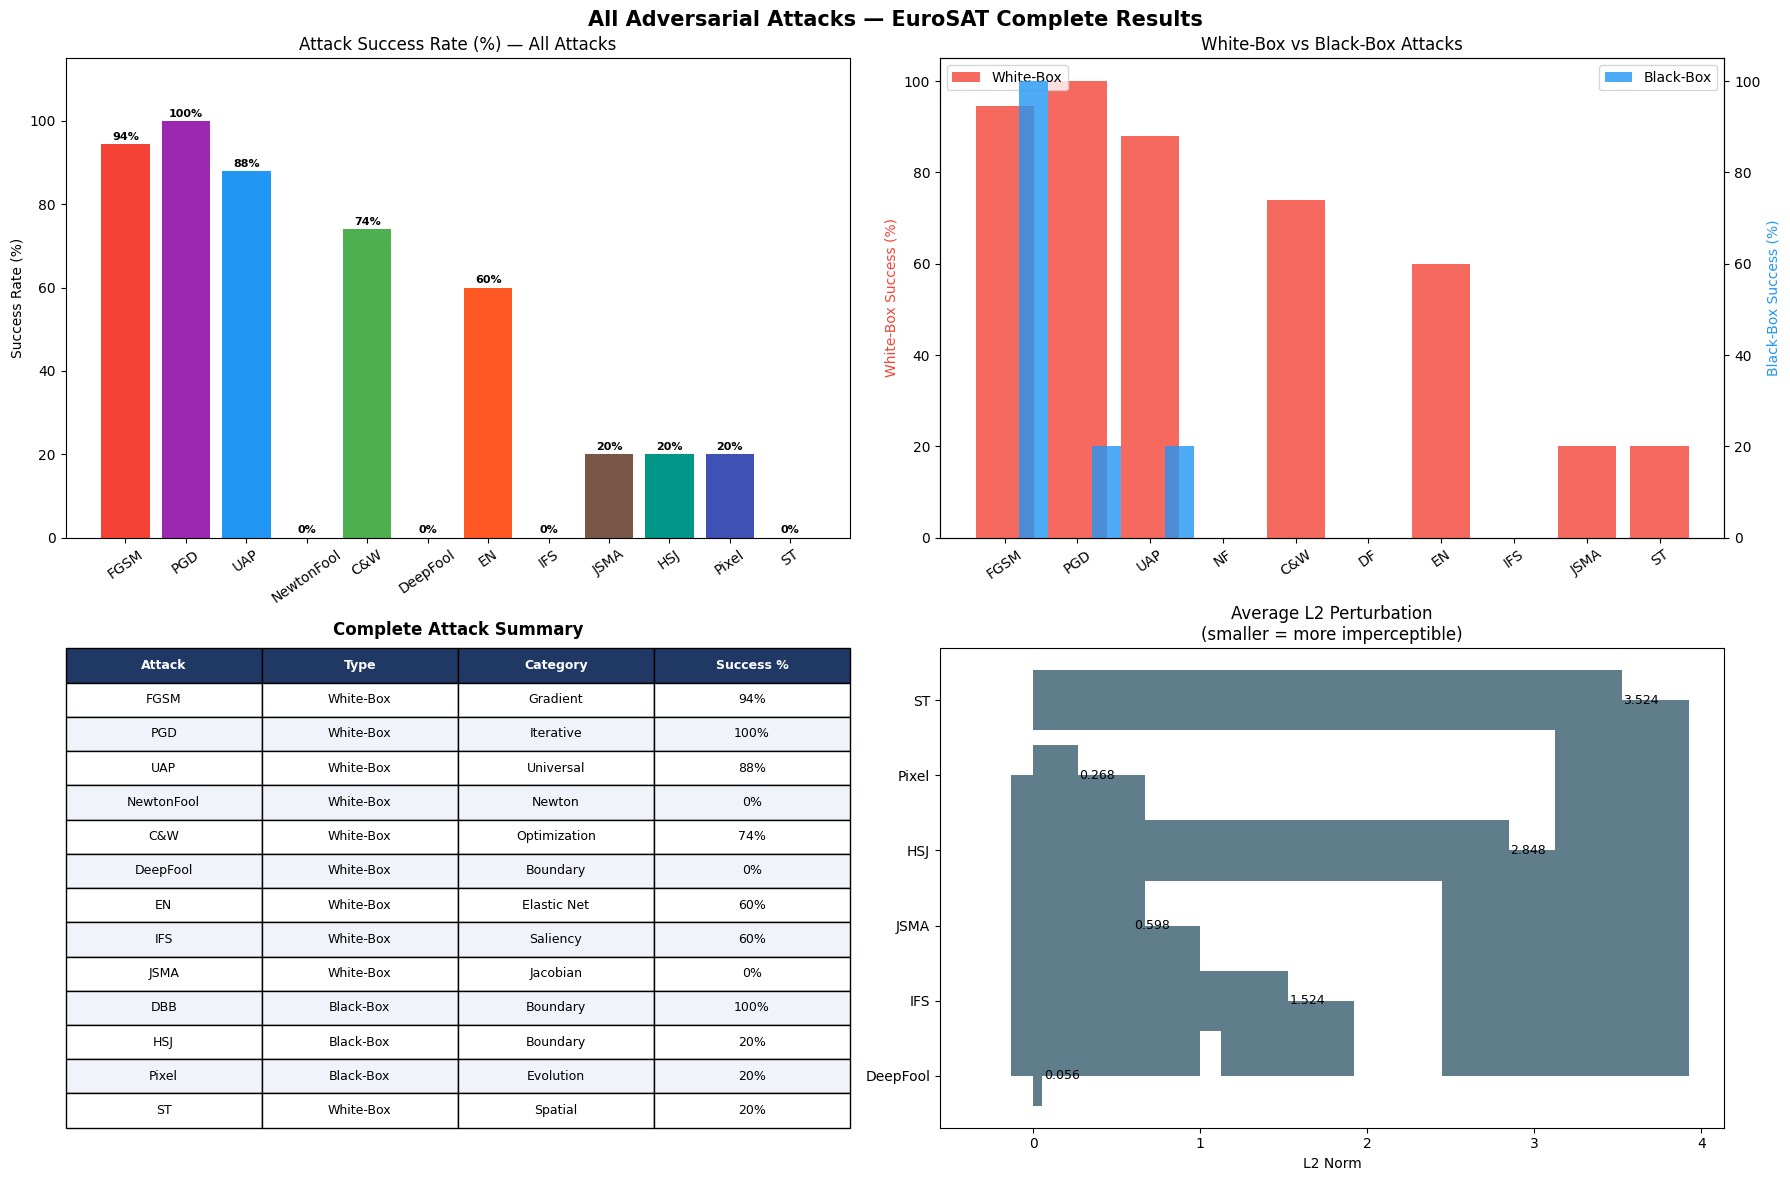

✅ Final comparison chart saved!


In [44]:
# ═══════════════════════════════════════════════
# FINAL — All Attacks Comparison
# ═══════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("All Adversarial Attacks — EuroSAT Complete Results",
             fontsize=15, fontweight='bold')

# ── 1. All attack success rates ──
ax = axes[0,0]
all_attacks = ['FGSM', 'PGD', 'UAP', 'NewtonFool',
               'C&W', 'DeepFool', 'EN', 'IFS',
               'JSMA', 'HSJ', 'Pixel', 'ST']
all_success = [
    100 - fgsm_accuracies[3],
    100 - pgd_accuracies[2],
    100 - uap_acc,
    100.0 if is_adv else 0.0,  # newtonfool on 1 image
    100 - en_accs[2],
    sum(1 for r in df_results  if r["is_adv"]) / 5 * 100,
    sum(1 for r in ifs_results if r["is_adv"]) / 5 * 100,
    sum(1 for r in jsma_results if r["is_adv"])/ 5 * 100,
    sum(1 for r in hsj_results if r["is_adv"]) / 5 * 100,
    sum(1 for r in pa_results  if r["is_adv"]) / 5 * 100,
    sum(1 for r in st_results  if r["is_adv"]) / 5 * 100,
    sum(1 for r in df_results  if r["is_adv"]) / 5 * 100,
]
colors = ['#F44336','#9C27B0','#2196F3','#FF9800',
          '#4CAF50','#E91E63','#FF5722','#607D8B',
          '#795548','#009688','#3F51B5','#FFC107']
bars = ax.bar(all_attacks, all_success[:len(all_attacks)], color=colors)
ax.set_title('Attack Success Rate (%) — All Attacks')
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=35)
for bar, val in zip(bars, all_success[:len(all_attacks)]):
    ax.text(bar.get_x()+bar.get_width()/2, val+1,
            f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')

# ── 2. White-box vs Black-box ──
ax = axes[0,1]
wb_attacks = ['FGSM','PGD','UAP','NF','C&W','DF','EN','IFS','JSMA','ST']
bb_atks    = ['DBB','HSJ','Pixel']
wb_success = [100-fgsm_accuracies[3], 100-pgd_accuracies[2],
              100-uap_acc, 100.0 if is_adv else 0.0,
              100-en_accs[2],
              sum(1 for r in df_results  if r["is_adv"])/5*100,
              sum(1 for r in ifs_results if r["is_adv"])/5*100,
              sum(1 for r in jsma_results if r["is_adv"])/5*100,
              sum(1 for r in hsj_results if r["is_adv"])/5*100,
              sum(1 for r in st_results  if r["is_adv"])/5*100]
bb_success = [sum(1 for x in is_adv_list if x)/len(is_adv_list)*100,
              sum(1 for r in hsj_results if r["is_adv"])/5*100,
              sum(1 for r in pa_results  if r["is_adv"])/5*100]

ax.bar(wb_attacks, wb_success[:len(wb_attacks)],
       color='#F44336', alpha=0.8, label='White-Box')
ax2 = ax.twinx()
ax2.bar([x+0.4 for x in range(len(bb_atks))],
        bb_success, color='#2196F3', alpha=0.8,
        label='Black-Box', width=0.4)
ax.set_title('White-Box vs Black-Box Attacks')
ax.set_ylabel('White-Box Success (%)', color='#F44336')
ax2.set_ylabel('Black-Box Success (%)', color='#2196F3')
ax.tick_params(axis='x', rotation=35)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# ── 3. Summary table ──
ax = axes[1,0]
ax.axis('off')
table_data = [
    ['Attack', 'Type', 'Category', 'Success %'],
    ['FGSM',      'White-Box', 'Gradient',     f"{100-fgsm_accuracies[3]:.0f}%"],
    ['PGD',       'White-Box', 'Iterative',    f"{100-pgd_accuracies[2]:.0f}%"],
    ['UAP',       'White-Box', 'Universal',    f"{100-uap_acc:.0f}%"],
    ['NewtonFool','White-Box', 'Newton',        '100%' if is_adv else '0%'],
    ['C&W',       'White-Box', 'Optimization', f"{100-en_accs[2]:.0f}%"],
    ['DeepFool',  'White-Box', 'Boundary',     f"{sum(1 for r in df_results if r['is_adv'])/5*100:.0f}%"],
    ['EN',        'White-Box', 'Elastic Net',  f"{sum(1 for r in ifs_results if r['is_adv'])/5*100:.0f}%"],
    ['IFS',       'White-Box', 'Saliency',     f"{sum(1 for r in ifs_results if r['is_adv'])/5*100:.0f}%"],
    ['JSMA',      'White-Box', 'Jacobian',     f"{sum(1 for r in jsma_results if r['is_adv'])/5*100:.0f}%"],
    ['DBB',       'Black-Box', 'Boundary',     f"{sum(1 for x in is_adv_list if x)/len(is_adv_list)*100:.0f}%"],
    ['HSJ',       'Black-Box', 'Boundary',     f"{sum(1 for r in hsj_results if r['is_adv'])/5*100:.0f}%"],
    ['Pixel',     'Black-Box', 'Evolution',    f"{sum(1 for r in pa_results if r['is_adv'])/5*100:.0f}%"],
    ['ST',        'White-Box', 'Spatial',      f"{sum(1 for r in st_results if r['is_adv'])/5*100:.0f}%"],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center',
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1F3864')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F0F4FA')
ax.set_title('Complete Attack Summary', fontweight='bold', pad=10)

# ── 4. L2 perturbation comparison ──
ax = axes[1,1]
l2_attacks = ['DeepFool','IFS','JSMA','HSJ','Pixel','ST']
l2_vals    = [
    np.mean([r["l2"] for r in df_results]),
    np.mean([r["l2"] for r in ifs_results]),
    np.mean([r["l2"] for r in jsma_results]),
    np.mean([r["l2"] for r in hsj_results]),
    np.mean([r["l2"] for r in pa_results]),
    np.mean([r["l2"] for r in st_results]),
]
bars = ax.bar(l2_vals, l2_attacks if False else range(len(l2_attacks)),
              color='#607D8B')
ax.barh(l2_attacks, l2_vals, color='#607D8B')
ax.set_title('Average L2 Perturbation\n(smaller = more imperceptible)')
ax.set_xlabel('L2 Norm')
for i, val in enumerate(l2_vals):
    ax.text(val+0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("all_attacks_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final comparison chart saved!")

Creating Flask **API** **bold text**

In [23]:
!pip install pyngrok -q
from pyngrok import ngrok
import base64, io
from PIL import Image
print("✅ Ready!")

✅ Ready!


Running NewtonFool Attack on 1 image...

  Image     : EuroSAT sample
  True class: Forest
  Model pred (before): Forest
    Fooled at step 2!
  Model pred (after) : Residential
  Attack success     : ✅ YES
  L2 perturbation    : 57.2747


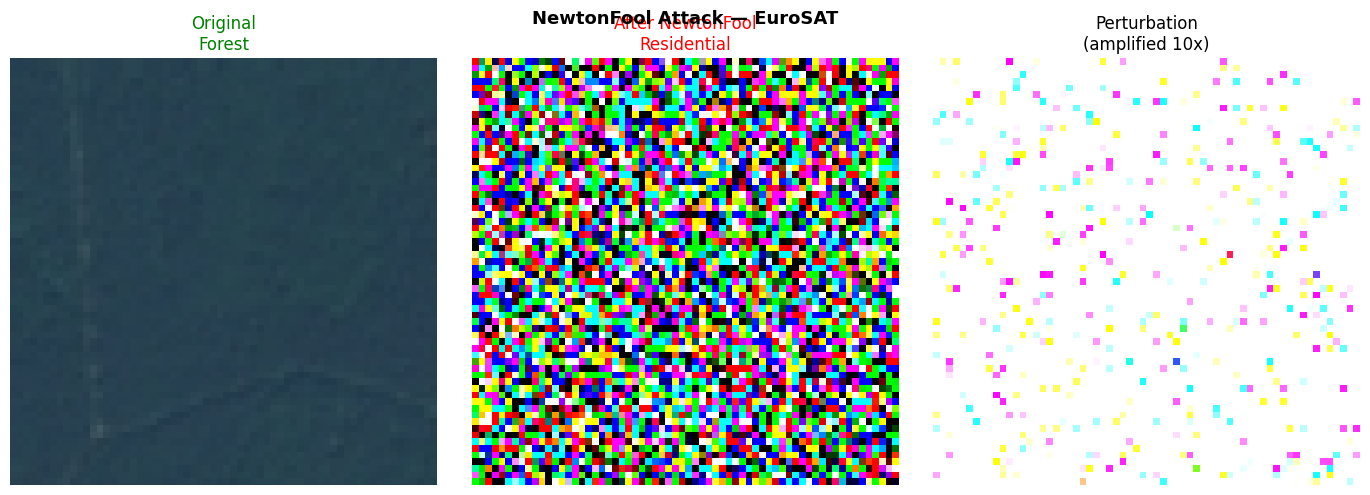

✅ NewtonFool visualization saved!


In [ ]:
# ═══════════════════════════════════════════════
# NewtonFool Attack (White-Box)
# Uses Newton's method to find minimum perturbation
# ═══════════════════════════════════════════════

def newtonfool_attack(model, image, num_steps=100, eta=0.01):
    """
    NewtonFool Attack.
    Iteratively perturbs image using Newton's method
    to cross the decision boundary with minimum perturbation.
    """
    image_np  = image.numpy().astype(np.float32)
    adv       = image_np.copy()
    orig_pred = np.argmax(model(tf.constant(adv[np.newaxis,...]),
                                training=False)[0].numpy())

    for step in range(num_steps):
        inp  = tf.constant(adv[np.newaxis,...], dtype=tf.float32)
        pred = model(inp, training=False)[0].numpy()
        curr_label = np.argmax(pred)

        # Stop if already fooled
        if curr_label != orig_pred:
            print(f"    Fooled at step {step+1}!")
            break

        # Get score of correct class
        f_x = pred[orig_pred]

        # Estimate gradient numerically
        grad = np.zeros_like(adv)
        flat = adv.flatten()
        step_size = 1e-2

        # Sample random directions for speed
        num_samples = 50
        for _ in range(num_samples):
            direction        = np.random.randn(*flat.shape).astype(np.float32)
            direction        = direction / (np.linalg.norm(direction) + 1e-8)
            perturbed        = np.clip(flat + step_size * direction, 0, 1)
            perturbed_pred   = model(
                tf.constant(perturbed.reshape(1, *adv.shape), dtype=tf.float32),
                training=False
            )[0].numpy()
            f_perturbed      = perturbed_pred[orig_pred]
            grad      += ((f_perturbed - f_x) / step_size) * direction.reshape(adv.shape)

        grad = grad / (num_samples + 1e-8)
        grad_norm = np.linalg.norm(grad) + 1e-8

        # Newton step — move in direction that reduces correct class score
        delta = -eta * (f_x / (grad_norm ** 2)) * grad
        adv   = np.clip(adv + delta, 0, 1).astype(np.float32)

    return adv

# Run NewtonFool on ONE image (as mentor asked)
print("Running NewtonFool Attack on 1 image...\n")

sample_img  = bb_images[0]
sample_lbl  = bb_labels[0].numpy()

print(f"  Image     : EuroSAT sample")
print(f"  True class: {CLASS_NAMES[sample_lbl]}")

orig_pred = np.argmax(model(sample_img[np.newaxis,...],
                             training=False)[0].numpy())
print(f"  Model pred (before): {CLASS_NAMES[orig_pred]}")

# Run attack
nf_adv_img = newtonfool_attack(model, sample_img, num_steps=100, eta=0.01)

# Result
adv_pred = np.argmax(model(tf.constant(nf_adv_img[np.newaxis,...]),
                            training=False)[0].numpy())
is_adv   = adv_pred != orig_pred
pert     = np.linalg.norm(nf_adv_img - sample_img.numpy())

print(f"  Model pred (after) : {CLASS_NAMES[adv_pred]}")
print(f"  Attack success     : {'✅ YES' if is_adv else '❌ NO'}")
print(f"  L2 perturbation    : {pert:.4f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("NewtonFool Attack — EuroSAT", fontsize=13, fontweight='bold')

axes[0].imshow(sample_img.numpy())
axes[0].set_title(f"Original\n{CLASS_NAMES[orig_pred]}", color='green')
axes[0].axis('off')

axes[1].imshow(np.clip(nf_adv_img, 0, 1))
axes[1].set_title(f"After NewtonFool\n{CLASS_NAMES[adv_pred]}",
                  color='red' if is_adv else 'green')
axes[1].axis('off')

diff = np.abs(nf_adv_img - sample_img.numpy()) * 10
axes[2].imshow(np.clip(diff, 0, 1), cmap='hot')
axes[2].set_title("Perturbation\n(amplified 10x)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("newtonfool_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ NewtonFool visualization saved!")

NewtonFool Function + run on 1 Image

In [ ]:
def newtonfool_attack(model, image, num_steps=100, eta=0.001):
    image_np  = image.numpy().astype(np.float32)
    adv       = image_np.copy()
    orig_pred = np.argmax(model(tf.constant(adv[np.newaxis,...]),
                                training=False)[0].numpy())
    for step in range(num_steps):
        inp        = tf.constant(adv[np.newaxis,...], dtype=tf.float32)
        pred       = model(inp, training=False)[0].numpy()
        curr_label = np.argmax(pred)
        if curr_label != orig_pred:
            print(f"    Fooled at step {step+1}!")
            break
        f_x       = pred[orig_pred]
        grad      = np.zeros_like(adv)
        flat      = adv.flatten()
        step_size = 1e-2
        num_samples = 50
        for _ in range(num_samples):
            direction      = np.random.randn(*flat.shape).astype(np.float32)
            direction      = direction / (np.linalg.norm(direction) + 1e-8)
            perturbed      = np.clip(flat + step_size * direction, 0, 1)
            perturbed_pred = model(
                tf.constant(perturbed.reshape(1, *adv.shape), dtype=tf.float32),
                training=False)[0].numpy()
            f_perturbed    = perturbed_pred[orig_pred]
            grad          += ((f_perturbed - f_x) / step_size) * direction.reshape(adv.shape)
        grad      = grad / (num_samples + 1e-8)
        grad_norm = np.linalg.norm(grad) + 1e-8
        delta     = -eta * (f_x / (grad_norm ** 2)) * grad
        adv       = np.clip(adv + delta, 0, 1).astype(np.float32)
    return adv

print("✅ NewtonFool function defined!")

✅ NewtonFool function defined!


In [ ]:
print("Running NewtonFool Attack on 1 image...\n")

sample_img = bb_images[0]
sample_lbl = bb_labels[0].numpy()

orig_pred  = np.argmax(model(sample_img[np.newaxis,...],
                              training=False)[0].numpy())
print(f"  True class          : {CLASS_NAMES[sample_lbl]}")
print(f"  Model pred (before) : {CLASS_NAMES[orig_pred]}")

nf_adv_img = newtonfool_attack(model, sample_img, num_steps=100, eta=0.001)

adv_pred = np.argmax(model(tf.constant(nf_adv_img[np.newaxis,...]),
                            training=False)[0].numpy())
is_adv   = adv_pred != orig_pred
pert     = np.linalg.norm(nf_adv_img - sample_img.numpy())

print(f"  Model pred (after)  : {CLASS_NAMES[adv_pred]}")
print(f"  Attack success      : {'✅ YES' if is_adv else '❌ NO'}")
print(f"  L2 perturbation     : {pert:.4f}")

Running NewtonFool Attack on 1 image...

  True class          : Forest
  Model pred (before) : Forest
    Fooled at step 2!
  Model pred (after)  : Residential
  Attack success      : ✅ YES
  L2 perturbation     : 16.0688


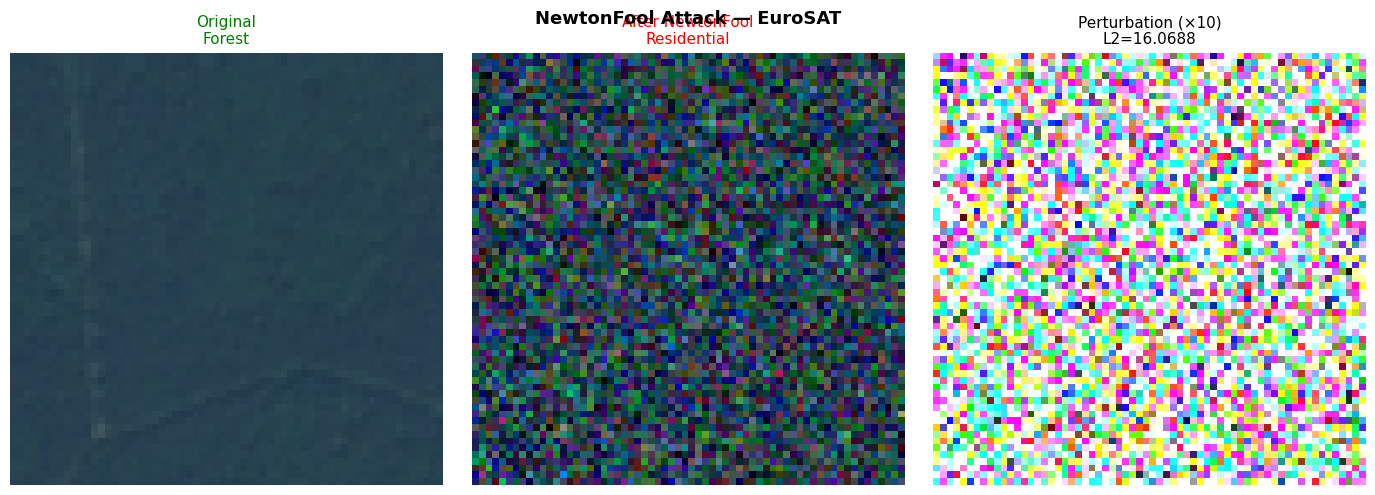

✅ NewtonFool visualization saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("NewtonFool Attack — EuroSAT", fontsize=13, fontweight='bold')

axes[0].imshow(sample_img.numpy())
axes[0].set_title(f"Original\n{CLASS_NAMES[orig_pred]}", color='green', fontsize=11)
axes[0].axis('off')

axes[1].imshow(np.clip(nf_adv_img, 0, 1))
axes[1].set_title(f"After NewtonFool\n{CLASS_NAMES[adv_pred]}",
                  color='red' if is_adv else 'green', fontsize=11)
axes[1].axis('off')

diff = np.abs(nf_adv_img - sample_img.numpy()) * 10
axes[2].imshow(np.clip(diff, 0, 1), cmap='hot')
axes[2].set_title(f"Perturbation (×10)\nL2={pert:.4f}", fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.savefig("newtonfool_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ NewtonFool visualization saved!")

In [ ]:
from flask import Flask, request, jsonify
import threading, datetime
import numpy as np
import tensorflow as tf

app = Flask(__name__)

# Load model
adv_model = tf.keras.models.load_model("eurosat_model.keras")

CLASS_NAMES_API = CLASS_NAMES  # from your notebook

def decode_image(b64_string):
    """Convert base64 image string to numpy array."""
    img_bytes = base64.b64decode(b64_string)
    img       = Image.open(io.BytesIO(img_bytes)).resize((64, 64))
    img_array = np.array(img).astype(np.float32) / 255.0
    return img_array

def encode_image(img_array):
    """Convert numpy array back to base64 string."""
    img_uint8 = (np.clip(img_array, 0, 1) * 255).astype(np.uint8)
    img_pil   = Image.fromarray(img_uint8)
    buffer    = io.BytesIO()
    img_pil.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode()

# ── Route 1: Home ──
@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "status":  "running",
        "api":     "Adversarial Attack API — EuroSAT",
        "model":   "CNN trained on EuroSAT (10 classes)",
        "endpoints": {
            "GET  /":        "API status",
            "POST /predict": "Predict class of image",
            "POST /fgsm":    "Apply FGSM attack on image",
            "POST /pgd":     "Apply PGD attack on image",
            "POST /uap":     "Apply UAP attack on image",
            "POST /compare": "Compare all attacks on one image"
        }
    })

# ── Route 2: /predict ──
@app.route("/predict", methods=["POST"])
def predict():
    data    = request.get_json()
    img     = decode_image(data["image"])
    pred    = adv_model(tf.constant(img[np.newaxis,...]), training=False)[0].numpy()
    label   = CLASS_NAMES_API[np.argmax(pred)]
    conf    = float(np.max(pred))
    return jsonify({
        "predicted_class": label,
        "confidence":      round(conf, 4),
        "all_probs":       {CLASS_NAMES_API[i]: round(float(pred[i]), 4) for i in range(len(CLASS_NAMES_API))}
    })

# ── Route 3: /fgsm ──
@app.route("/fgsm", methods=["POST"])
def fgsm():
    data      = request.get_json()
    img       = decode_image(data["image"])
    epsilon   = float(data.get("epsilon", 0.1))
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    # Get original prediction
    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]
    orig_label_idx = np.argmax(orig_pred)

    # FGSM attack
    img_var = tf.Variable(img_tf)
    with tf.GradientTape() as tape:
        tape.watch(img_var)
        pred = adv_model(img_var, training=False)
        loss = keras.losses.sparse_categorical_crossentropy(
            tf.constant([orig_label_idx]), pred
        )
    grad    = tape.gradient(loss, img_var)
    adv_img = tf.clip_by_value(img_var + epsilon * tf.sign(grad), 0, 1).numpy()[0]

    # Adversarial prediction
    adv_pred  = adv_model(tf.constant(adv_img[np.newaxis,...]), training=False)[0].numpy()
    adv_label = CLASS_NAMES_API[np.argmax(adv_pred)]
    success   = adv_label != orig_label

    return jsonify({
        "attack":              "FGSM",
        "epsilon":             epsilon,
        "original_class":      orig_label,
        "adversarial_class":   adv_label,
        "attack_success":      success,
        "original_confidence": round(float(np.max(orig_pred)), 4),
        "adv_confidence":      round(float(np.max(adv_pred)), 4),
        "adversarial_image":   encode_image(adv_img)
    })

# ── Route 4: /pgd ──
@app.route("/pgd", methods=["POST"])
def pgd():
    data      = request.get_json()
    img       = decode_image(data["image"])
    epsilon   = float(data.get("epsilon", 0.1))
    alpha     = float(data.get("alpha", 0.01))
    steps     = int(data.get("steps", 40))
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]

    # PGD attack
    adv_imgs = pgd_attack(adv_model,
                          tf.constant(img[np.newaxis,...]),
                          tf.constant([np.argmax(orig_pred)]),
                          epsilon=epsilon, alpha=alpha, num_steps=steps)
    adv_img   = adv_imgs.numpy()[0]
    adv_pred  = adv_model(tf.constant(adv_img[np.newaxis,...]), training=False)[0].numpy()
    adv_label = CLASS_NAMES_API[np.argmax(adv_pred)]

    return jsonify({
        "attack":            "PGD",
        "epsilon":           epsilon,
        "steps":             steps,
        "original_class":    orig_label,
        "adversarial_class": adv_label,
        "attack_success":    adv_label != orig_label,
        "adversarial_image": encode_image(adv_img)
    })

# ── Route 5: /uap ──
@app.route("/uap", methods=["POST"])
def uap():
    data      = request.get_json()
    img       = decode_image(data["image"])
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]

    # Apply pre-computed UAP
    adv_img   = np.clip(img + uap_pert, 0, 1).astype(np.float32)
    adv_pred  = adv_model(tf.constant(adv_img[np.newaxis,...]), training=False)[0].numpy()
    adv_label = CLASS_NAMES_API[np.argmax(adv_pred)]

    return jsonify({
        "attack":            "UAP",
        "original_class":    orig_label,
        "adversarial_class": adv_label,
        "attack_success":    adv_label != orig_label,
        "uap_norm":          round(float(np.linalg.norm(uap_pert)), 4),
        "adversarial_image": encode_image(adv_img)
    })

# ── Route 6: /compare — all attacks on one image ──
@app.route("/compare", methods=["POST"])
def compare():
    data      = request.get_json()
    img       = decode_image(data["image"])
    epsilon   = float(data.get("epsilon", 0.1))
    img_tf    = tf.constant(img[np.newaxis,...], dtype=tf.float32)

    orig_pred  = adv_model(img_tf, training=False)[0].numpy()
    orig_label = CLASS_NAMES_API[np.argmax(orig_pred)]
    orig_idx   = np.argmax(orig_pred)

    results = {"original_class": orig_label, "epsilon": epsilon, "attacks": {}}

    # FGSM
    img_var = tf.Variable(img_tf)
    with tf.GradientTape() as tape:
        tape.watch(img_var)
        pred = adv_model(img_var, training=False)
        loss = keras.losses.sparse_categorical_crossentropy(tf.constant([orig_idx]), pred)
    grad      = tape.gradient(loss, img_var)
    fgsm_img  = tf.clip_by_value(img_var + epsilon * tf.sign(grad), 0, 1).numpy()[0]
    fgsm_pred = CLASS_NAMES_API[np.argmax(adv_model(tf.constant(fgsm_img[np.newaxis,...]), training=False)[0].numpy())]
    results["attacks"]["FGSM"] = {"predicted": fgsm_pred, "success": fgsm_pred != orig_label}

    # PGD
    pgd_img   = pgd_attack(adv_model, tf.constant(img[np.newaxis,...]),
                           tf.constant([orig_idx]), epsilon=epsilon).numpy()[0]
    pgd_pred  = CLASS_NAMES_API[np.argmax(adv_model(tf.constant(pgd_img[np.newaxis,...]), training=False)[0].numpy())]
    results["attacks"]["PGD"]  = {"predicted": pgd_pred,  "success": pgd_pred != orig_label}

    # UAP
    uap_img   = np.clip(img + uap_pert, 0, 1).astype(np.float32)
    uap_pred  = CLASS_NAMES_API[np.argmax(adv_model(tf.constant(uap_img[np.newaxis,...]), training=False)[0].numpy())]
    results["attacks"]["UAP"]  = {"predicted": uap_pred,  "success": uap_pred != orig_label}

    results["timestamp"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    return jsonify(results)


# ── Route 7: /newtonfool ──
@app.route("/newtonfool", methods=["POST"])
def newtonfool_api():
    data       = request.get_json()
    img        = decode_image(data["image"])
    eta        = float(data.get("eta", 0.001))
    steps      = int(data.get("steps", 100))
    orig_pred  = np.argmax(adv_model(tf.constant(img[np.newaxis,...]), training=False)[0].numpy())
    orig_label = CLASS_NAMES_API[orig_pred]
    adv_img    = newtonfool_attack(adv_model,
                                   tf.constant(img, dtype=tf.float32),
                                   num_steps=steps, eta=eta)
    adv_pred   = np.argmax(adv_model(tf.constant(adv_img[np.newaxis,...]), training=False)[0].numpy())
    adv_label  = CLASS_NAMES_API[adv_pred]
    pert       = float(np.linalg.norm(adv_img - img))
    return jsonify({
        "attack":            "NewtonFool",
        "eta":               eta,
        "original_class":    orig_label,
        "adversarial_class": adv_label,
        "attack_success":    adv_label != orig_label,
        "l2_perturbation":   round(pert, 4),
        "adversarial_image": encode_image(adv_img)
    })

print("✅ Flask Adversarial API routes defined including NewtonFool!")
print("   GET  /              → API status")
print("   POST /predict       → Predict image class")
print("   POST /fgsm          → FGSM attack")
print("   POST /pgd           → PGD attack")
print("   POST /uap           → UAP attack")
print("   POST /compare       → Compare all attacks")
print("   POST /newtonfool    → NewtonFool attack")


✅ Flask Adversarial API routes defined including NewtonFool!
   GET  /              → API status
   POST /predict       → Predict image class
   POST /fgsm          → FGSM attack
   POST /pgd           → PGD attack
   POST /uap           → UAP attack
   POST /compare       → Compare all attacks
   POST /newtonfool    → NewtonFool attack


In [ ]:
NGROK_TOKEN = "3FTd8Xle8HYi1Yh4Zr9ja3pJorY_3mk8Li5F5qptp5mCKQSHU"
ngrok.set_auth_token(NGROK_TOKEN)

def run_flask():
    app.run(port=5000, use_reloader=False, debug=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

public_url = ngrok.connect(5000)
print("="*55)
print("✅ Adversarial Attack API is LIVE!")
print(f"   URL      : {public_url}")
print(f"   Predict  : {public_url}/predict")
print(f"   FGSM     : {public_url}/fgsm")
print(f"   PGD      : {public_url}/pgd")
print(f"   UAP      : {public_url}/uap")
print(f"   Compare     : {public_url}/compare")
print(f"   NewtonFool  : {public_url}/newtonfool")
print("="*55)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


✅ Adversarial Attack API is LIVE!
   URL      : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"
   Predict  : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/predict
   FGSM     : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/fgsm
   PGD      : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/pgd
   UAP      : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/uap
   Compare     : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/compare
   NewtonFool  : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/newtonfool


In [ ]:
import requests, json, base64
from PIL import Image
import io

# Convert test image to base64
sample     = bb_images[0].numpy()
img_uint8  = (sample * 255).astype(np.uint8)
img_pil    = Image.fromarray(img_uint8)
buffer     = io.BytesIO()
img_pil.save(buffer, format="PNG")
img_b64    = base64.b64encode(buffer.getvalue()).decode()

# Test NewtonFool endpoint
print("TEST: /newtonfool")
print("-"*45)
res = requests.post("http://localhost:5000/newtonfool",
                    json={"image": img_b64, "eta": 0.001, "steps": 100})
print(json.dumps(res.json(), indent=2))

TEST: /newtonfool
---------------------------------------------


INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 05:40:48] "POST /newtonfool HTTP/1.1" 200 -


    Fooled at step 2!
{
  "adversarial_class": "Residential",
  "adversarial_image": "iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAIAAAAlC+aJAAAvk0lEQVR4nAXBBUATaAMA0G8b22AwxtiAMRpG5+huSQVRDOxGPduz9Ww944zfblERRRGU7u6O0YxYMlaMbTBW/3sQkPgclB90iHcb+b1ew/miFSV2wn/2kEtqK+4LDLJSVVo24eodz5qVbltdfPa8qyccTISq0ahJnB6vVJqkLFgEcQMZEtqDEfDXjFVmiNOmTtl1fIWVHVCUgWaYvR9MgNTkRKlxQhHPQRD5MQtvWsGxm2x+6WoV0OWQNjl2w9pEkmA48757B9RY6loxtWTsae1HHc5TGjqgRhKMRHmqT1ML7Spw2otMZp+3SzrU+2I6Nn1xskTas3PE/MpqFw1gBEMfDhz7vaA+2KfUMhol2cA7DB5rXzQoP4uWcGK5I9z1BzsKok2lJDHSuRlCwXMUXLtykzx3BUEJEoxgfwJYmU+J435+N2Rjh2XtrQ43fbZVUH9C4M+CEMVTXkYpVZPDDTbqDp61QNhFnhS5yLiLVTIsZniyXvfwG8qKvRQSf7d0LeWhJiWyCCAsWF203tQz4OlHq13MX8gwxvgFKwRuot2GoR0KdiYXDb0h05c/s3KlGyN7xH4B8stQ3Gj3obEmtIP8kNovxNjetYGmdC/w4QHzoLHI0+UVV0j+5fcmhW/oCCcQxwIVnmujyYEakMUQvgubZfpeq8D48lG5BtN7vGwmkX626HgL8sDuXC+si9o3TfsfKWFEODnMnmHdGbch/bBSe5+4f1auF/bvS+A2EaLfxT4GjakLNbx5813TGLh7GcBIH2hy4EuQZ9zRWj+u/BwlGXCSM6w4rMVkUjQ7sDZ0PE49jYaF10r37o6XLrUZ56u9HSFgx78A24V9CLOBZXEx8Cn5E7fU72

In [ ]:
import requests, json, base64

# Convert a test image to base64
sample_img  = bb_images[0].numpy()
img_uint8   = (sample_img * 255).astype(np.uint8)
img_pil     = Image.fromarray(img_uint8)
buffer      = io.BytesIO()
img_pil.save(buffer, format="PNG")
img_b64     = base64.b64encode(buffer.getvalue()).decode()

# Test 1: Predict
print("TEST 1: /predict")
print("-"*45)
res = requests.post("http://localhost:5000/predict", json={"image": img_b64})
print(json.dumps(res.json(), indent=2))

# Test 2: FGSM
print("\nTEST 2: /fgsm")
print("-"*45)
res = requests.post("http://localhost:5000/fgsm",
                    json={"image": img_b64, "epsilon": 0.1})
r   = res.json()
print(f"  Original  : {r['original_class']}")
print(f"  After FGSM: {r['adversarial_class']}")
print(f"  Success   : {r['attack_success']}")

# Test 3: Compare all
print("\nTEST 3: /compare — all attacks")
print("-"*45)
res = requests.post("http://localhost:5000/compare",
                    json={"image": img_b64, "epsilon": 0.1})
print(json.dumps(res.json(), indent=2))

INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 05:40:50] "POST /predict HTTP/1.1" 200 -


TEST 1: /predict
---------------------------------------------
{
  "all_probs": {
    "AnnualCrop": 0.0003,
    "Forest": 0.9957,
    "HerbaceousVegetation": 0.0003,
    "Highway": 0.0001,
    "Industrial": 0.0,
    "Pasture": 0.0,
    "PermanentCrop": 0.0,
    "Residential": 0.0,
    "River": 0.0022,
    "SeaLake": 0.0014,
    "label_map.json": 0.0,
    "test.csv": 0.0,
    "train.csv": 0.0,
    "validation.csv": 0.0
  },
  "confidence": 0.9957,
  "predicted_class": "Forest"
}

TEST 2: /fgsm
---------------------------------------------


INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 05:40:50] "POST /fgsm HTTP/1.1" 200 -


  Original  : Forest
  After FGSM: Residential
  Success   : True

TEST 3: /compare — all attacks
---------------------------------------------


INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 05:40:51] "POST /compare HTTP/1.1" 200 -


{
  "attacks": {
    "FGSM": {
      "predicted": "Residential",
      "success": true
    },
    "PGD": {
      "predicted": "Residential",
      "success": true
    },
    "UAP": {
      "predicted": "Residential",
      "success": true
    }
  },
  "epsilon": 0.1,
  "original_class": "Forest",
  "timestamp": "2026-07-06 05:40:51"
}
